In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nbme-manual-feature-classification/feature_classification.csv
/kaggle/input/nbme-cleaned-predictions/nbme_cleaned_predictions/biomistral_predictions_cleaned.csv
/kaggle/input/nbme-cleaned-predictions/nbme_cleaned_predictions/qwen_predictions_cleaned.csv
/kaggle/input/nbme-cleaned-predictions/nbme_cleaned_predictions/gemma_predictions_cleaned.csv
/kaggle/input/nbme-cleaned-predictions/nbme_cleaned_predictions/mistral_predictions_cleaned.csv
/kaggle/input/nbme-score-clinical-patient-notes/sample_submission.csv
/kaggle/input/nbme-score-clinical-patient-notes/patient_notes.csv
/kaggle/input/nbme-score-clinical-patient-notes/features.csv
/kaggle/input/nbme-score-clinical-patient-notes/train.csv
/kaggle/input/nbme-score-clinical-patient-notes/test.csv


In [2]:
"""
CORRECTED NBME EVALUATION - PHASE 1: DATA LOADING AND VALIDATION
=================================================================
ADAPTED: Works with cleaned prediction files from inference phase
"""

import pandas as pd
import numpy as np
import ast
import re
from pathlib import Path

# ============================================================================
# CONFIGURATION
# ============================================================================

# ✅ UPDATED: Point to cleaned prediction files (from inference phase)
MODEL_FILES = {
    "mistral": "/kaggle/input/nbme-cleaned-predictions/nbme_cleaned_predictions/mistral_predictions_cleaned.csv",
    "gemma": "/kaggle/input/nbme-cleaned-predictions/nbme_cleaned_predictions/gemma_predictions_cleaned.csv",
    "qwen": "/kaggle/input/nbme-cleaned-predictions/nbme_cleaned_predictions/qwen_predictions_cleaned.csv",
    "biomistral": "/kaggle/input/nbme-cleaned-predictions/nbme_cleaned_predictions/biomistral_predictions_cleaned.csv"
}

NBME_PATH = "/kaggle/input/nbme-score-clinical-patient-notes"

# ✅ UPDATED: Cleaned files use 'predictions' column (standardized)
PRED_COL = "predictions"  # All cleaned files should have this column

# ============================================================================
# STEP 1.1: LOAD MODEL PREDICTIONS (FIXED: Use ast.literal_eval)
# ============================================================================

def parse_list_safe(x):
    """
    FIXED: Use ast.literal_eval instead of eval() for safety.
    """
    if isinstance(x, list):
        return x
    if pd.isna(x) or x == "" or x is None:
        return []
    
    try:
        # SAFE parsing with ast.literal_eval
        return ast.literal_eval(str(x))
    except (ValueError, SyntaxError) as e:
        print(f"⚠️  Warning: Could not parse: {str(x)[:100]} | Error: {e}")
        return []


def load_model_predictions(file_path, model_name):
    """
    Load a single model's predictions with validation.
    
    ADAPTED: Works with cleaned prediction files that have:
    - 'pn_num' column
    - 'predictions' column (string representation of list)
    """
    print(f"\n{'='*70}")
    print(f"Loading {model_name.upper()}")
    print(f"{'='*70}")
    
    # Load CSV
    df = pd.read_csv(file_path)
    print(f"✓ Loaded {len(df)} rows")
    
    # ✅ CHECK: Verify required columns exist
    if 'pn_num' not in df.columns:
        raise ValueError(f"Missing 'pn_num' column in {file_path}")
    
    if PRED_COL not in df.columns:
        raise ValueError(f"Missing '{PRED_COL}' column in {file_path}. Available: {df.columns.tolist()}")
    
    print(f"✓ Found required columns: pn_num, {PRED_COL}")
    
    # ✅ FIXED: Safe parsing with ast.literal_eval
    df['predictions'] = df[PRED_COL].apply(parse_list_safe)
    
    # Basic validation
    total = len(df)
    unique_notes = df['pn_num'].nunique()
    duplicates = total - unique_notes
    
    print(f"✓ Unique notes: {unique_notes}")
    if duplicates > 0:
        print(f"⚠️  Warning: {duplicates} duplicate pn_num values found")
        # ✅ DEDUP: Remove duplicates (keep first occurrence)
        df = df.drop_duplicates(subset='pn_num', keep='first')
        print(f"  → Removed duplicates, now {len(df)} rows")
    
    # Check for missing values
    missing_pn = df['pn_num'].isna().sum()
    missing_pred = df['predictions'].apply(lambda x: x == []).sum()
    
    print(f"✓ Missing pn_num: {missing_pn}")
    print(f"✓ Empty predictions: {missing_pred} ({missing_pred/total*100:.1f}%)")
    
    # ✅ CHECK: Verify predictions are lists
    non_list = df['predictions'].apply(lambda x: not isinstance(x, list)).sum()
    if non_list > 0:
        print(f"⚠️  Warning: {non_list} predictions are not lists (will be fixed)")
        df['predictions'] = df['predictions'].apply(
            lambda x: x if isinstance(x, list) else []
        )
    
    # Sample predictions
    has_preds = df['predictions'].apply(lambda x: len(x) > 0)
    if has_preds.any():
        sample_idx = has_preds.idxmax()
        print(f"\nSample prediction:")
        print(f"  pn_num: {df.loc[sample_idx, 'pn_num']}")
        print(f"  predictions ({len(df.loc[sample_idx, 'predictions'])} items):")
        for i, pred in enumerate(df.loc[sample_idx, 'predictions'][:3], 1):
            print(f"    {i}. {pred}")
    else:
        print("\n⚠️  Warning: No non-empty predictions found!")
    
    return df[['pn_num', 'predictions']].copy()


# ============================================================================
# LOAD ALL MODELS
# ============================================================================

print(f"\n{'='*70}")
print("LOADING ALL MODEL PREDICTIONS")
print(f"{'='*70}")

all_predictions_raw = {}

for model_name, file_path in MODEL_FILES.items():
    try:
        all_predictions_raw[model_name] = load_model_predictions(file_path, model_name)
    except FileNotFoundError:
        print(f"\n❌ Error: File not found: {file_path}")
        print(f"   Please upload {model_name}_predictions_cleaned.csv")
    except Exception as e:
        print(f"\n❌ Error loading {model_name}: {e}")

if len(all_predictions_raw) == 0:
    raise RuntimeError("❌ CRITICAL: No model predictions loaded! Check file paths.")

print(f"\n{'='*70}")
print(f"SUMMARY: Loaded {len(all_predictions_raw)}/4 models successfully")
print(f"{'='*70}")

# ============================================================================
# STEP 1.2: LOAD NBME GROUND TRUTH
# ============================================================================

print(f"\n{'='*70}")
print("Loading NBME Ground Truth")
print(f"{'='*70}")

# Load NBME files
features = pd.read_csv(f"{NBME_PATH}/features.csv")
train = pd.read_csv(f"{NBME_PATH}/train.csv")

print(f"✓ Loaded features: {len(features)} total features")
print(f"✓ Loaded train: {len(train)} annotations")

# Create feature mapping (feature_num -> feature_text)
feature_map = features.set_index("feature_num")["feature_text"].to_dict()

print(f"\nSample features:")
for feat_num in list(feature_map.keys())[:5]:
    print(f"  {feat_num}: {feature_map[feat_num]}")

# Create gold standard (all features) - pn_num -> list of feature texts
gold_df_all = (
    train.groupby("pn_num")["feature_num"]
    .apply(lambda x: list({feature_map[f] for f in x}))
    .reset_index()
    .rename(columns={"feature_num": "gold"})
)

print(f"\n✓ Created gold standard for {len(gold_df_all)} notes")
print(f"  Average features per note: {gold_df_all['gold'].apply(len).mean():.1f}")

# Sample gold annotations
if len(gold_df_all) > 0:
    sample_note = gold_df_all.iloc[0]
    print(f"\nSample gold annotations (pn_num={sample_note['pn_num']}):")
    for symptom in sample_note['gold'][:5]:
        print(f"  - {symptom}")

# ============================================================================
# STEP 1.3: DATA QUALITY CHECKS
# ============================================================================

print(f"\n{'='*70}")
print("Data Quality Checks")
print(f"{'='*70}")

# Check 1: Note coverage across models
all_pn_nums = [set(df['pn_num']) for df in all_predictions_raw.values()]
common_notes = set.intersection(*all_pn_nums)
all_notes = set.union(*all_pn_nums)

print(f"\n1. Note Coverage:")
print(f"  Common notes across all models: {len(common_notes)}")
print(f"  Total unique notes: {len(all_notes)}")

for model_name, df in all_predictions_raw.items():
    model_notes = set(df['pn_num'])
    missing = len(all_notes - model_notes)
    if missing > 0:
        print(f"  ⚠️  {model_name}: missing {missing} notes")
    else:
        print(f"  ✓ {model_name}: complete ({len(model_notes)} notes)")

# Check 2: Gold standard coverage
gold_notes = set(gold_df_all['pn_num'])
print(f"\n2. Gold Standard Coverage:")
print(f"  Notes with gold annotations: {len(gold_notes)}")

for model_name, df in all_predictions_raw.items():
    model_notes = set(df['pn_num'])
    without_gold = len(model_notes - gold_notes)
    with_gold = len(model_notes & gold_notes)
    if without_gold > 0:
        print(f"  ⚠️  {model_name}: {without_gold} notes without gold (will be excluded)")
    print(f"  ✓ {model_name}: {with_gold} notes with gold annotations")

# Check 3: Prediction statistics
print(f"\n3. Prediction Statistics:")

for model_name, df in all_predictions_raw.items():
    avg_len = df['predictions'].apply(len).mean()
    max_len = df['predictions'].apply(len).max()
    empty_count = (df['predictions'].apply(len) == 0).sum()
    
    print(f"\n  {model_name.upper()}:")
    print(f"    Average symptoms: {avg_len:.1f}")
    print(f"    Max symptoms: {max_len}")
    print(f"    Empty predictions: {empty_count} ({empty_count/len(df)*100:.1f}%)")

# ============================================================================
# SAVE INTERMEDIATE OUTPUTS
# ============================================================================

print(f"\n{'='*70}")
print("Saving Intermediate Outputs")
print(f"{'='*70}")

# Save raw predictions (for next phase)
for model_name, df in all_predictions_raw.items():
    output_path = f"/kaggle/working/{model_name}_predictions_raw.csv"
    df.to_csv(output_path, index=False)
    print(f"✓ Saved: {output_path}")

# Save gold standard
gold_df_all.to_csv("/kaggle/working/gold_standard_all_features.csv", index=False)
print(f"✓ Saved: gold_standard_all_features.csv")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print(f"\n{'='*70}")
print("PHASE 1 COMPLETE - Data Loading Summary")
print(f"{'='*70}")

summary_stats = []
for model_name, df in all_predictions_raw.items():
    # Count notes with gold coverage
    model_notes = set(df['pn_num'])
    covered_notes = len(model_notes & gold_notes)
    
    summary_stats.append({
        'Model': model_name,
        'Total Predictions': len(df),
        'Unique Notes': df['pn_num'].nunique(),
        'With Gold Coverage': covered_notes,
        'Empty Predictions': (df['predictions'].apply(len) == 0).sum(),
        'Avg Symptoms': df['predictions'].apply(len).mean()
    })

summary_df = pd.DataFrame(summary_stats)
print("\n", summary_df.to_string(index=False))

print(f"\nGold Standard: {len(gold_df_all)} notes with annotations")
print(f"Average gold features per note: {gold_df_all['gold'].apply(len).mean():.1f}")

print("\n✅ Phase 1 Complete: Data successfully loaded and validated")
print("\n📝 Important Notes:")
print("  - Used cleaned prediction files (no annotation required)")
print("  - Removed any duplicate pn_num values")
print("  - All predictions parsed safely with ast.literal_eval")
print("  - Notes without gold standard will be excluded in evaluation")

print("\nReady for Phase 2: Initial Diagnostic Analysis")


LOADING ALL MODEL PREDICTIONS

Loading MISTRAL
✓ Loaded 1000 rows
✓ Found required columns: pn_num, predictions
✓ Unique notes: 1000
✓ Missing pn_num: 0
✓ Empty predictions: 0 (0.0%)

Sample prediction:
  pn_num: 16
  predictions (6 items):
    1. palpitations
    2. chest pressure
    3. passing out feeling

Loading GEMMA
✓ Loaded 1000 rows
✓ Found required columns: pn_num, predictions
✓ Unique notes: 1000
✓ Missing pn_num: 0
✓ Empty predictions: 0 (0.0%)

Sample prediction:
  pn_num: 16
  predictions (12 items):
    1. only extract patient-reported symptoms or clinician-observed findings.
    2. use only the clinical note provided.
    3. do not include diagnoses, medications, procedures, labs, demographics, family history, ros, pmh, or social history.

Loading QWEN
✓ Loaded 1000 rows
✓ Found required columns: pn_num, predictions
✓ Unique notes: 1000
✓ Missing pn_num: 0
✓ Empty predictions: 0 (0.0%)

Sample prediction:
  pn_num: 16
  predictions (3 items):
    1. 'palpitations'
    

Loaded 4 models

STEP 2.1: Symptom Count Statistics


MISTRAL
  Mean:   5.57
  Median: 5.0
  Std:    2.32
  Range:  1 - 13


GEMMA
  Mean:   10.84
  Median: 10.0
  Std:    2.45
  Range:  6 - 22


QWEN
  Mean:   4.68
  Median: 4.0
  Std:    2.96
  Range:  1 - 15


BIOMISTRAL
  Mean:   1.01
  Median: 1.0
  Std:    0.11
  Range:  1 - 3

STEP 2.2: Empty Prediction Detection

MISTRAL:
  Truly empty: 0 (0.0%)
  'None' only: 0 (0.0%)
  Total empty: 0 (0.0%)

GEMMA:
  Truly empty: 0 (0.0%)
  'None' only: 0 (0.0%)
  Total empty: 0 (0.0%)

QWEN:
  Truly empty: 0 (0.0%)
  'None' only: 145 (14.5%)
  Total empty: 145 (14.5%)

BIOMISTRAL:
  Truly empty: 0 (0.0%)
  'None' only: 246 (24.6%)
  Total empty: 246 (24.6%)

STEP 2.3: Instruction Leakage Detection

MISTRAL:
  Leakage detected: 9/1000 (0.9%)

GEMMA:
  Leakage detected: 1000/1000 (100.0%)

QWEN:
  Leakage detected: 0/1000 (0.0%)

BIOMISTRAL:
  Leakage detected: 0/1000 (0.0%)

Creating Visualizations...


/tmp/ipykernel_55/2313499882.py:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


✓ Saved: viz_01_avg_symptoms.png


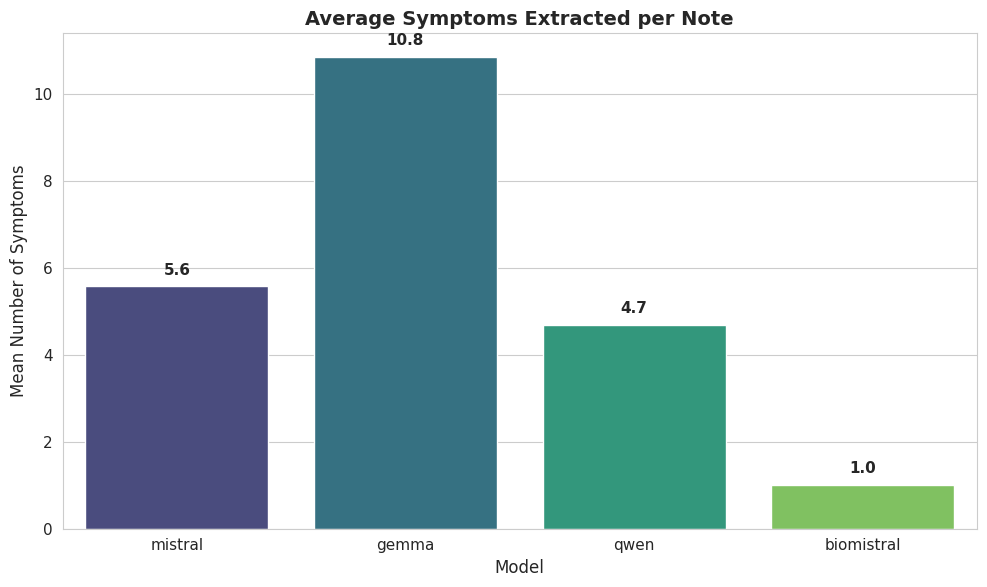

/tmp/ipykernel_55/2313499882.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


✓ Saved: viz_02_empty_predictions.png


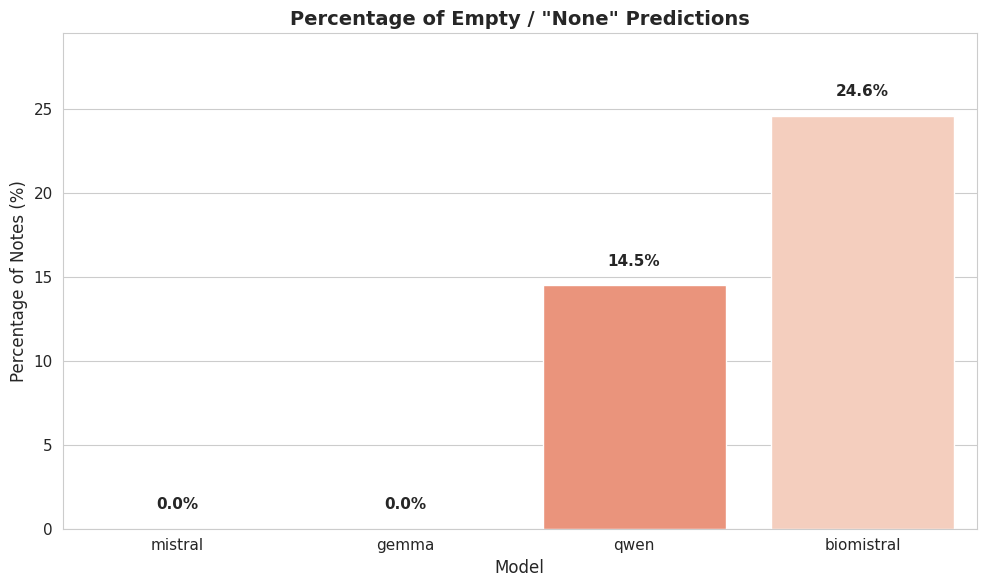

/tmp/ipykernel_55/2313499882.py:219: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


✓ Saved: viz_03_instruction_leakage.png


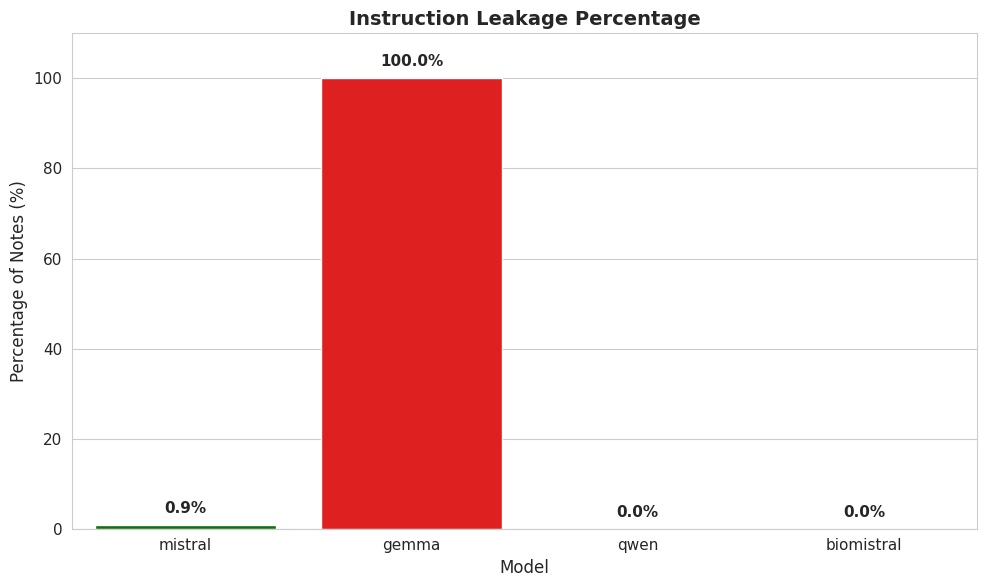

✓ Saved: viz_04_radar_chart.png


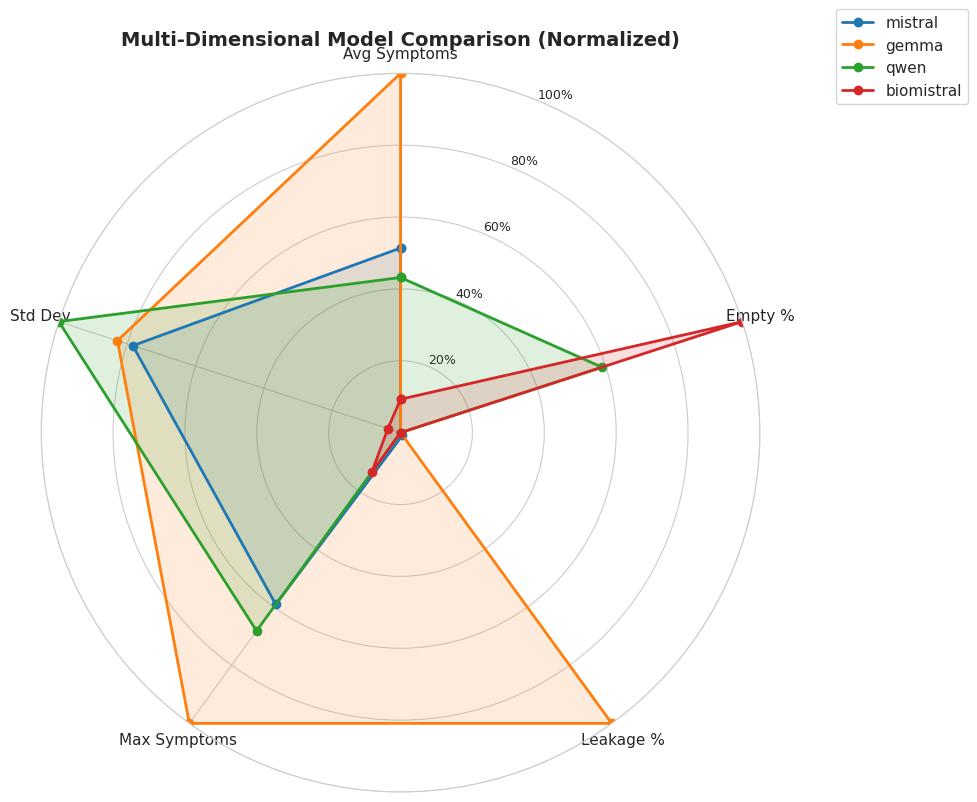


✅ Phase 2 Complete


In [3]:
"""
CORRECTED NBME EVALUATION - PHASE 2: INITIAL DIAGNOSTIC ANALYSIS
================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ast
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# ============================================================================
# LOAD DATA FROM PHASE 1
# ============================================================================

all_predictions_raw = {}
for model in ["mistral", "gemma", "qwen", "biomistral"]:
    df = pd.read_csv(f"/kaggle/working/{model}_predictions_raw.csv")
    # FIXED: Use ast.literal_eval
    df['predictions'] = df['predictions'].apply(ast.literal_eval)
    all_predictions_raw[model] = df

print(f"Loaded {len(all_predictions_raw)} models")

# ============================================================================
# STEP 2.1: SYMPTOM COUNT STATISTICS
# ============================================================================

print(f"\n{'='*70}")
print("STEP 2.1: Symptom Count Statistics")
print(f"{'='*70}")

symptom_stats = []

for model_name, df in all_predictions_raw.items():
    df['symptom_count'] = df['predictions'].apply(len)
    
    stats = {
        'Model': model_name,
        'Mean': df['symptom_count'].mean(),
        'Median': df['symptom_count'].median(),
        'Std': df['symptom_count'].std(),
        'Min': df['symptom_count'].min(),
        'Max': df['symptom_count'].max(),
        'Q1': df['symptom_count'].quantile(0.25),
        'Q3': df['symptom_count'].quantile(0.75)
    }
    
    symptom_stats.append(stats)
    
    model_label = model_name.upper()
    print(f"\n")
    print(model_label)
    print(f"  Mean:   {stats['Mean']:.2f}")
    print(f"  Median: {stats['Median']:.1f}")
    print(f"  Std:    {stats['Std']:.2f}")
    print(f"  Range:  {stats['Min']} - {stats['Max']}")

symptom_stats_df = pd.DataFrame(symptom_stats)

# ============================================================================
# STEP 2.2: EMPTY PREDICTION DETECTION
# ============================================================================

print(f"\n{'='*70}")
print("STEP 2.2: Empty Prediction Detection")
print(f"{'='*70}")

empty_stats = []

for model_name, df in all_predictions_raw.items():
    truly_empty = (df['predictions'].apply(len) == 0).sum()
    
    none_only = df['predictions'].apply(
        lambda x: len(x) == 1 and (x[0].lower() == 'none' if x else False)
    ).sum()
    
    total_empty = df['predictions'].apply(
        lambda x: len(x) == 0 or (len(x) == 1 and x[0].lower() == 'none')
    ).sum()
    
    total = len(df)
    
    stats = {
        'Model': model_name,
        'Truly Empty': truly_empty,
        'None Only': none_only,
        'Total Empty/None': total_empty,
        'Percentage': (total_empty / total) * 100
    }
    
    empty_stats.append(stats)
    
    print(f"\n{model_name.upper()}:")
    print(f"  Truly empty: {truly_empty} ({truly_empty/total*100:.1f}%)")
    print(f"  'None' only: {none_only} ({none_only/total*100:.1f}%)")
    print(f"  Total empty: {total_empty} ({total_empty/total*100:.1f}%)")

empty_stats_df = pd.DataFrame(empty_stats)

# ============================================================================
# STEP 2.3: INSTRUCTION LEAKAGE DETECTION
# ============================================================================

print(f"\n{'='*70}")
print("STEP 2.3: Instruction Leakage Detection")
print(f"{'='*70}")

INSTRUCTION_PATTERNS = [
    r'based on.{0,20}(note|text|information)',
    r'here (are|is).{0,20}symptom',
    r'extract(ed|ing|ion)?.{0,20}symptom',
    r'following symptom',
    r'identified.{0,20}symptom',
    r'patient.{0,20}(presents|has|reports).{0,20}following',
    r'symptoms? (mentioned|noted|found|identified)',
    r'i (will|have|can).{0,20}(extract|identify|list)',
]

instruction_regex = re.compile('|'.join(INSTRUCTION_PATTERNS), re.IGNORECASE)

leakage_stats = []

for model_name, df in all_predictions_raw.items():
    leakage_detected = df['predictions'].apply(
        lambda symptoms: any(
            instruction_regex.search(str(s)) for s in symptoms
        )
    ).sum()
    
    total = len(df)
    pct = (leakage_detected / total) * 100
    
    stats = {
        'Model': model_name,
        'Notes with Leakage': leakage_detected,
        'Total Notes': total,
        'Percentage': pct
    }
    
    leakage_stats.append(stats)
    
    print(f"\n{model_name.upper()}:")
    print(f"  Leakage detected: {leakage_detected}/{total} ({pct:.1f}%)")

leakage_stats_df = pd.DataFrame(leakage_stats)

# ============================================================================
# VISUALIZATION 1: AVERAGE SYMPTOMS EXTRACTED
# ============================================================================

print(f"\n{'='*70}")
print("Creating Visualizations...")
print(f"{'='*70}")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=symptom_stats_df,
    x='Model',
    y='Mean',
    palette='viridis'
)
plt.title('Average Symptoms Extracted per Note', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Mean Number of Symptoms', fontsize=12)
plt.xticks(rotation=0)

# Add value labels on bars
for i, row in symptom_stats_df.iterrows():
    plt.text(i, row['Mean'] + 0.2, f"{row['Mean']:.1f}", 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/viz_01_avg_symptoms.png', dpi=300, bbox_inches='tight')
print("✓ Saved: viz_01_avg_symptoms.png")
plt.show()

# ============================================================================
# VISUALIZATION 2: EMPTY PREDICTIONS PERCENTAGE
# ============================================================================

plt.figure(figsize=(10, 6))
sns.barplot(
    data=empty_stats_df,
    x='Model',
    y='Percentage',
    palette='Reds_r'
)
plt.title('Percentage of Empty / "None" Predictions', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Percentage of Notes (%)', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, max(empty_stats_df['Percentage']) * 1.2)

# Add value labels
for i, row in empty_stats_df.iterrows():
    plt.text(i, row['Percentage'] + 1, f"{row['Percentage']:.1f}%", 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/viz_02_empty_predictions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: viz_02_empty_predictions.png")
plt.show()

# ============================================================================
# VISUALIZATION 3: INSTRUCTION LEAKAGE PERCENTAGE
# ============================================================================

plt.figure(figsize=(10, 6))
colors = ['red' if x > 50 else 'orange' if x > 10 else 'green' 
          for x in leakage_stats_df['Percentage']]

sns.barplot(
    data=leakage_stats_df,
    x='Model',
    y='Percentage',
    palette=colors
)
plt.title('Instruction Leakage Percentage', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Percentage of Notes (%)', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, max(leakage_stats_df['Percentage']) * 1.1 if max(leakage_stats_df['Percentage']) > 0 else 10)

# Add value labels
for i, row in leakage_stats_df.iterrows():
    plt.text(i, row['Percentage'] + 2, f"{row['Percentage']:.1f}%", 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/viz_03_instruction_leakage.png', dpi=300, bbox_inches='tight')
print("✓ Saved: viz_03_instruction_leakage.png")
plt.show()

# ============================================================================
# VISUALIZATION 4: RADAR CHART (MULTI-DIMENSIONAL COMPARISON)
# ============================================================================

from math import pi

# Normalize metrics to 0-1 scale for radar chart
radar_data = []

for model_name in ['mistral', 'gemma', 'qwen', 'biomistral']:
    # Get stats for this model
    symp_stats = symptom_stats_df[symptom_stats_df['Model'] == model_name].iloc[0]
    emp_stats = empty_stats_df[empty_stats_df['Model'] == model_name].iloc[0]
    leak_stats = leakage_stats_df[leakage_stats_df['Model'] == model_name].iloc[0]
    
    radar_data.append({
        'Model': model_name,
        'Avg Symptoms': symp_stats['Mean'],
        'Empty %': emp_stats['Percentage'],
        'Leakage %': leak_stats['Percentage'],
        'Max Symptoms': symp_stats['Max'],
        'Std Dev': symp_stats['Std']
    })

radar_df = pd.DataFrame(radar_data)

# Normalize to 0-1
metrics = ['Avg Symptoms', 'Empty %', 'Leakage %', 'Max Symptoms', 'Std Dev']
for metric in metrics:
    max_val = radar_df[metric].max()
    if max_val > 0:
        radar_df[f'{metric}_norm'] = radar_df[metric] / max_val
    else:
        radar_df[f'{metric}_norm'] = 0

# Create radar chart
categories = metrics
N = len(categories)

# Compute angle for each axis
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Initialize plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Plot each model
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for idx, (_, row) in enumerate(radar_df.iterrows()):
    values = [row[f'{m}_norm'] for m in metrics]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

# Fix axis to go in the right order
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

# Draw axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)

# Configure grid
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], size=9)
ax.grid(True)

# Add legend
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.title('Multi-Dimensional Model Comparison (Normalized)', 
          size=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('/kaggle/working/viz_04_radar_chart.png', dpi=300, bbox_inches='tight')
print("✓ Saved: viz_04_radar_chart.png")
plt.show()

# Save diagnostic summary
symptom_stats_df.to_csv('/kaggle/working/nbme_symptom_stats.csv', index=False)
empty_stats_df.to_csv('/kaggle/working/nbme_empty_stats.csv', index=False)
leakage_stats_df.to_csv('/kaggle/working/nbme_leakage_stats.csv', index=False)

print("\n✅ Phase 2 Complete")


APPLYING POST-PROCESSING

Processing MISTRAL...
  Raw symptoms: 5572
  Post-processed: 5536
  Removed: 36 (0.6%)

Processing GEMMA...
  Raw symptoms: 10843
  Post-processed: 8812
  Removed: 2031 (18.7%)

Processing QWEN...
  Raw symptoms: 4682
  Post-processed: 4516
  Removed: 166 (3.5%)

Processing BIOMISTRAL...
  Raw symptoms: 1008
  Post-processed: 1008
  Removed: 0 (0.0%)

RAW vs POST-PROCESSED SUMMARY
     Model  Raw Mean  Post Mean  Raw Empty  Post Empty
   mistral     5.572      5.536          0           0
     gemma    10.843      8.812          0           0
      qwen     4.682      4.516        145         147
biomistral     1.008      1.008        246         253

Creating Before/After Visualizations...
✓ Saved: viz_05_before_after_symptoms.png


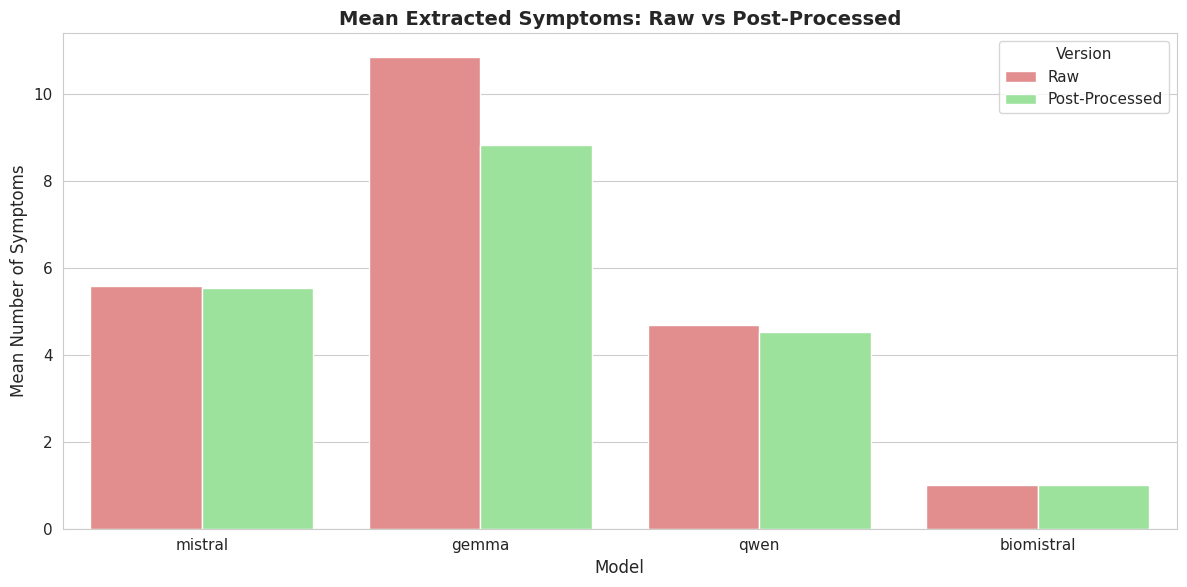

✓ Saved: viz_06_before_after_empty.png


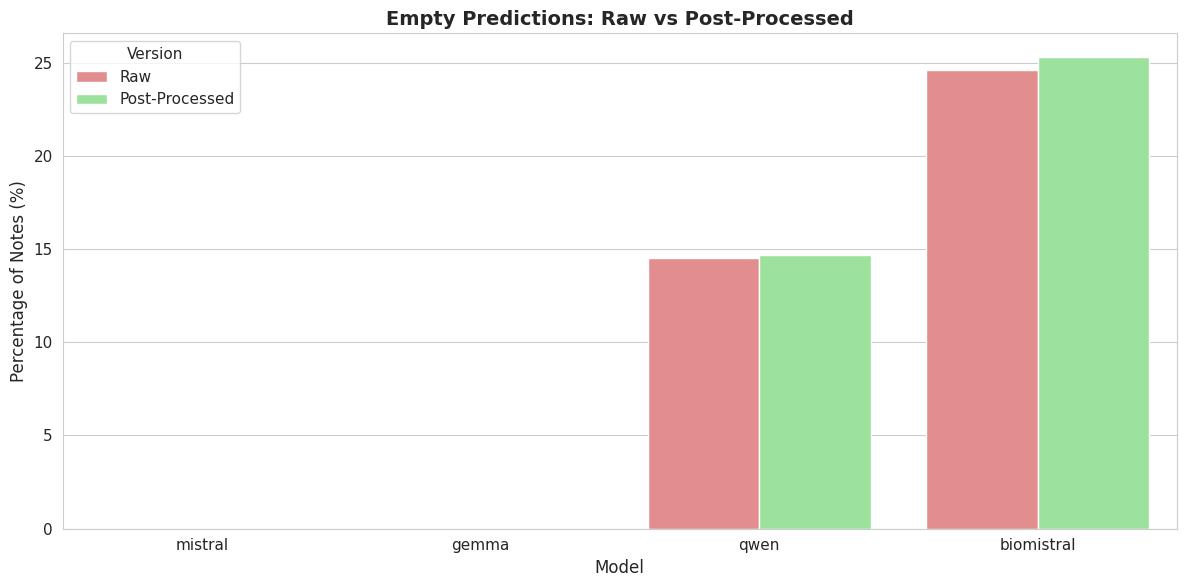


Example Transformations

GEMMA - Examples where post-processing removed items:

  Note 60407:
    Raw (18 items):
      - only extract patient-reported symptoms or clinician-observed findings.
      - use only the clinical note provided.
      - do not include diagnoses, medications, procedures, labs, demographics, family hi
      - do not include negated symptoms.
      - do not infer or assume symptoms.
    Post-processed (13 items):
      - use only the clinical note provided
      - do not include negated symptoms
      - do not infer or assume symptoms
      - output must be either
      - 17yr male with l sided sharp chest pain with deep breaths also endorses stuffy n

  Note 20169:
    Raw (19 items):
      - only extract patient-reported symptoms or clinician-observed findings.
      - use only the clinical note provided.
      - do not include diagnoses, medications, procedures, labs, demographics, family hi
      - do not include negated symptoms.
      - do not infer or ass

In [4]:
"""
CORRECTED NBME EVALUATION - PHASE 3: POST-PROCESSING
====================================================
CRITICAL FIX: Clearly separate raw vs post-processed evaluation
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ast

# ============================================================================
# POST-PROCESSING FUNCTIONS (Same as before)
# ============================================================================

INSTRUCTION_PATTERN = re.compile(
    r'based on.{0,20}(note|text|information)|'
    r'here (are|is).{0,20}symptom|'
    r'extract(ed|ing|ion)?.{0,20}symptom|'
    r'following symptom|'
    r'identified.{0,20}symptom|'
    r'patient.{0,20}(presents|has|reports).{0,20}following|'
    r'symptoms? (mentioned|noted|found|identified)|'
    r'i (will|have|can).{0,20}(extract|identify|list)',
    re.IGNORECASE
)

NON_SYMPTOM_PATTERN = re.compile(
    r'(family|personal|social).{0,20}history|'
    r'(father|mother|sister|brother).{0,20}(has|had|died)|'
    r'(smok(es|ing|er)|alcohol|drug).{0,20}(use|abuse|history)|'
    r'married|divorced|occupation|works? (as|at)|'
    r'year.{0,5}old|age.{0,5}\d+',
    re.IGNORECASE
)

def normalize_symptom(s):
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = re.sub(r'[\"\'`]', '', s)
    s = re.sub(r'[^a-z0-9\s-]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def postprocess_predictions(raw_predictions):
    """Clean predictions - instruction leakage, normalization, deduplication."""
    if not isinstance(raw_predictions, list):
        return []
    
    symptoms = []
    
    for symptom in raw_predictions:
        if not isinstance(symptom, str):
            continue
        
        if INSTRUCTION_PATTERN.search(symptom):
            continue
        
        if NON_SYMPTOM_PATTERN.search(symptom):
            continue
        
        normalized = normalize_symptom(symptom)
        
        if not normalized or len(normalized) < 2:
            continue
        
        symptoms.append(normalized)
    
    if len(symptoms) > 1:
        symptoms = [s for s in symptoms if s != 'none']
    
    seen = set()
    unique_symptoms = []
    for s in symptoms:
        if s not in seen:
            seen.add(s)
            unique_symptoms.append(s)
    
    if len(unique_symptoms) == 0:
        return ['none']
    
    return unique_symptoms

# ============================================================================
# APPLY POST-PROCESSING
# ============================================================================

print(f"\n{'='*70}")
print("APPLYING POST-PROCESSING")
print(f"{'='*70}")

all_predictions_post = {}

for model in ["mistral", "gemma", "qwen", "biomistral"]:
    df = pd.read_csv(f"/kaggle/working/{model}_predictions_raw.csv")
    df['predictions'] = df['predictions'].apply(ast.literal_eval)
    
    print(f"\nProcessing {model.upper()}...")
    
    df['predictions_postprocessed'] = df['predictions'].apply(postprocess_predictions)
    
    raw_count = df['predictions'].apply(len).sum()
    post_count = df['predictions_postprocessed'].apply(len).sum()
    removed = raw_count - post_count
    
    print(f"  Raw symptoms: {raw_count}")
    print(f"  Post-processed: {post_count}")
    print(f"  Removed: {removed} ({removed/raw_count*100:.1f}%)")
    
    # Save BOTH versions
    df[['pn_num', 'predictions']].to_csv(
        f"/kaggle/working/{model}_predictions_raw_clean.csv", index=False
    )
    
    df[['pn_num', 'predictions_postprocessed']].rename(
        columns={'predictions_postprocessed': 'predictions'}
    ).to_csv(
        f"/kaggle/working/{model}_predictions_postprocessed.csv", index=False
    )
    
    all_predictions_post[model] = df

# ============================================================================
# RAW VS POST-PROCESSED COMPARISON STATS
# ============================================================================

comparison_stats = []

for model, df in all_predictions_post.items():
    raw_preds = df['predictions']
    post_preds = df['predictions_postprocessed']
    
    stats = {
        'Model': model,
        'Raw Mean': raw_preds.apply(len).mean(),
        'Post Mean': post_preds.apply(len).mean(),
        'Raw Empty': (raw_preds.apply(lambda x: x == [] or x == ['none'])).sum(),
        'Post Empty': (post_preds.apply(lambda x: x == ['none'])).sum(),
    }
    
    comparison_stats.append(stats)

comparison_df = pd.DataFrame(comparison_stats)

print("\nRAW vs POST-PROCESSED SUMMARY")
print(comparison_df.to_string(index=False))

# ============================================================================
# VISUALIZATION 5: BEFORE/AFTER AVERAGE SYMPTOMS
# ============================================================================

print(f"\n{'='*70}")
print("Creating Before/After Visualizations...")
print(f"{'='*70}")

# Reshape data for grouped bar chart
plot_data = []
for _, row in comparison_df.iterrows():
    plot_data.append({'Model': row['Model'], 'Type': 'Raw', 'Mean Symptoms': row['Raw Mean']})
    plot_data.append({'Model': row['Model'], 'Type': 'Post-Processed', 'Mean Symptoms': row['Post Mean']})

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x='Model',
    y='Mean Symptoms',
    hue='Type',
    palette=['lightcoral', 'lightgreen']
)
plt.title('Mean Extracted Symptoms: Raw vs Post-Processed', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Mean Number of Symptoms', fontsize=12)
plt.legend(title='Version', fontsize=11)
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('/kaggle/working/viz_05_before_after_symptoms.png', dpi=300, bbox_inches='tight')
print("✓ Saved: viz_05_before_after_symptoms.png")
plt.show()

# ============================================================================
# VISUALIZATION 6: BEFORE/AFTER EMPTY PREDICTIONS
# ============================================================================

# Reshape data for empty predictions
plot_data_empty = []
for _, row in comparison_df.iterrows():
    total = 1000  # Assuming 1000 notes
    plot_data_empty.append({
        'Model': row['Model'], 
        'Type': 'Raw', 
        'Empty %': (row['Raw Empty'] / total) * 100
    })
    plot_data_empty.append({
        'Model': row['Model'], 
        'Type': 'Post-Processed', 
        'Empty %': (row['Post Empty'] / total) * 100
    })

plot_df_empty = pd.DataFrame(plot_data_empty)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df_empty,
    x='Model',
    y='Empty %',
    hue='Type',
    palette=['lightcoral', 'lightgreen']
)
plt.title('Empty Predictions: Raw vs Post-Processed', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Percentage of Notes (%)', fontsize=12)
plt.legend(title='Version', fontsize=11)
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('/kaggle/working/viz_06_before_after_empty.png', dpi=300, bbox_inches='tight')
print("✓ Saved: viz_06_before_after_empty.png")
plt.show()

# ============================================================================
# EXAMPLE TRANSFORMATIONS
# ============================================================================

print(f"\n{'='*70}")
print("Example Transformations")
print(f"{'='*70}")

for model in ["gemma", "mistral"]:  # Show examples from 2 models
    df = all_predictions_post[model]
    
    # Find cases where post-processing made significant changes
    df['change'] = df.apply(
        lambda row: len(row['predictions']) - len(row['predictions_postprocessed']),
        axis=1
    )
    
    # Get examples with largest changes
    significant_changes = df.nlargest(3, 'change')
    
    if len(significant_changes) > 0:
        print(f"\n{model.upper()} - Examples where post-processing removed items:")
        for idx, row in significant_changes.iterrows():
            print(f"\n  Note {row['pn_num']}:")
            print(f"    Raw ({len(row['predictions'])} items):")
            for item in row['predictions'][:5]:
                print(f"      - {item[:80]}")
            print(f"    Post-processed ({len(row['predictions_postprocessed'])} items):")
            for item in row['predictions_postprocessed'][:5]:
                print(f"      - {item[:80]}")

print("\n✅ Phase 3 Complete: Both raw and post-processed versions saved")
print("\n📝 NOTE: Main evaluation will use post-processed predictions")
print("   (Raw evaluation available for ablation study)")

In [5]:
#The total list of features of nbme

import csv, json

path = '/kaggle/input/nbme-score-clinical-patient-notes/features.csv'
with open(path, newline='', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    if 'feature_text' not in reader.fieldnames:
        raise SystemExit(f"feature_text not in columns: {reader.fieldnames}")
    feature_text = [row['feature_text'] for row in reader]

SYMPTOM FEATURE IDENTIFICATION (USING MANUAL CLASSIFICATION)

✅ Loading manual feature classification...
✓ Loaded 143 features from manual classification file
✓ Verified columns: ['feature_num', 'feature_text', 'is_symptom']

MANUAL CLASSIFICATION RESULTS:
Total features: 143
Symptom features: 60 (42.0%)
Non-symptom features: 83 (58.0%)

SYMPTOM FEATURES (60 total):
    2: Chest-pressure
    4: Lightheaded
    7: Shortness-of-breath
    9: heart-pounding-OR-heart-racing
  101: Weight-loss
  107: Right-sided-LQ-abdominal-pain-OR-Right-lower-quadrant-abdominal-pain
  109: Diminished-appetite
  204: Vaginal-dryness
  205: Irregular-menses
  206: Recent-nausea-vomiting-OR-Recent-flulike-symptoms
  211: Hot-flashes
  212: Irregular-flow-OR-Irregular-frequency-OR-Irregular-intervals
  214: Heavy-sweating
  215: Sleep-disturbance-OR-Early-awakenings
  301: Epigastric-discomfort
  302: Darker-bowel-movements
  304: burning-OR-gnawing-OR-burning-and-gnawing
  305: Post-prandial-bloating-OR-full

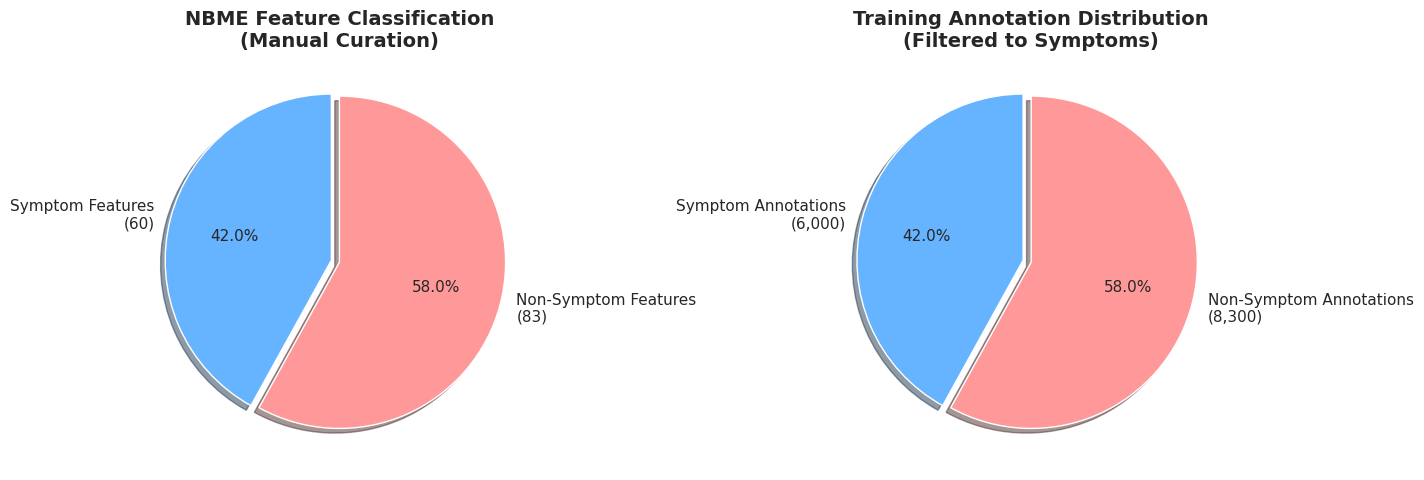

✓ Saved: viz_symptom_count_distribution.png


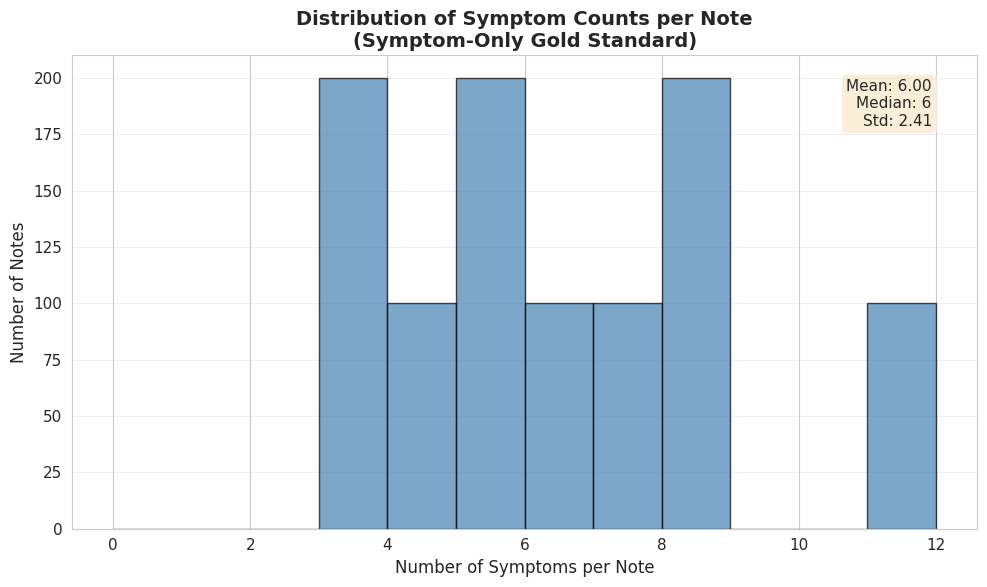


Saving Outputs
✓ Saved: gold_standard_symptom_only.csv
✓ Saved: gold_standard_comparison.csv
✓ Saved: feature_classification_used.csv (copy of manual classification)

PHASE 4 COMPLETE - SYMPTOM-ONLY GOLD STANDARD

📊 Summary:
  Total NBME Features: 143
  Symptom Features: 60
  Non-Symptom Features: 83
  Total Annotations: 14,300
  Symptom Annotations: 6,000
  Removed Annotations: 8,300
  Notes with Gold: 1,000
  Notes without Symptoms: 0
  Avg Symptoms/Note: 6.00

✅ Phase 4 Complete: Using MANUAL feature classification

📝 Key Points:
  ✓ Loaded manual classification from: /kaggle/input/nbme-manual-feature-classification/feature_classification.csv
  ✓ 60 symptom features retained
  ✓ 83 non-symptom features excluded
  ✓ Symptom-only gold standard created for evaluation

🎯 Next Steps:
  - Use 'gold_standard_symptom_only.csv' for evaluation
  - This ensures fair evaluation aligned with symptom extraction task
  - Evaluating on 60 symptom features (vs 143 total)

Ready for Phase 5: Core Me

In [6]:
"""
CORRECTED NBME EVALUATION - PHASE 4: SYMPTOM-ONLY GOLD STANDARD
================================================================
USING MANUAL FEATURE CLASSIFICATION (feature_classification.csv)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# LOAD NBME DATA
# ============================================================================

NBME_PATH = "/kaggle/input/nbme-score-clinical-patient-notes"
train = pd.read_csv(f"{NBME_PATH}/train.csv")

print(f"{'='*70}")
print("SYMPTOM FEATURE IDENTIFICATION (USING MANUAL CLASSIFICATION)")
print(f"{'='*70}")

# ============================================================================
# ✅ LOAD YOUR MANUAL CLASSIFICATION
# ============================================================================

# Load your manually curated feature classification
FEATURE_CLASS_PATH = "/kaggle/input/nbme-manual-feature-classification/feature_classification.csv"  # UPDATE THIS PATH

print("\n✅ Loading manual feature classification...")
features = pd.read_csv(FEATURE_CLASS_PATH)

print(f"✓ Loaded {len(features)} features from manual classification file")

# Verify required columns exist
required_cols = ['feature_num', 'feature_text', 'is_symptom']
missing_cols = [col for col in required_cols if col not in features.columns]

if missing_cols:
    raise ValueError(f"❌ Missing required columns: {missing_cols}")

print(f"✓ Verified columns: {features.columns.tolist()}")

# Normalize is_symptom to boolean
features['is_symptom'] = features['is_symptom'].map({
    True: True,
    False: False,
    'Yes': True,
    'No': False,
    'YES': True,
    'NO': False
})

if features['is_symptom'].isna().any():
    raise ValueError("❌ Some features have invalid is_symptom values")

# ============================================================================
# DISPLAY CLASSIFICATION RESULTS
# ============================================================================

# Separate symptom vs non-symptom features
symptom_features = features[features['is_symptom'] == True]
non_symptom_features = features[features['is_symptom'] == False]

print(f"\n{'='*70}")
print("MANUAL CLASSIFICATION RESULTS:")
print(f"{'='*70}")
print(f"Total features: {len(features)}")
print(f"Symptom features: {len(symptom_features)} ({len(symptom_features)/len(features)*100:.1f}%)")
print(f"Non-symptom features: {len(non_symptom_features)} ({len(non_symptom_features)/len(features)*100:.1f}%)")

# Display symptom features
print(f"\n{'='*70}")
print(f"SYMPTOM FEATURES ({len(symptom_features)} total):")
print(f"{'='*70}")
for idx, row in symptom_features.iterrows():
    print(f"  {row['feature_num']:3d}: {row['feature_text']}")

# Display non-symptom features
print(f"\n{'='*70}")
print(f"NON-SYMPTOM FEATURES ({len(non_symptom_features)} total - EXCLUDED):")
print(f"{'='*70}")
for idx, row in non_symptom_features.iterrows():
    print(f"  {row['feature_num']:3d}: {row['feature_text']}")

# ============================================================================
# CREATE SYMPTOM-ONLY GOLD STANDARD
# ============================================================================

print(f"\n{'='*70}")
print("CREATING SYMPTOM-ONLY GOLD STANDARD")
print(f"{'='*70}")

# Create feature mapping (feature_num -> feature_text)
feature_map = dict(zip(features['feature_num'], features['feature_text']))

# Get symptom feature numbers
symptom_feature_nums = set(symptom_features['feature_num'].tolist())

print(f"\nSymptom feature numbers: {sorted(symptom_feature_nums)}")

# Filter training data to symptom features only
train_symptom_only = train[train['feature_num'].isin(symptom_feature_nums)]

print(f"\nFiltering training annotations:")
print(f"  Original annotations: {len(train):,}")
print(f"  Symptom-only annotations: {len(train_symptom_only):,}")
print(f"  Removed (non-symptom): {len(train) - len(train_symptom_only):,} ({(len(train) - len(train_symptom_only))/len(train)*100:.1f}%)")

# Create symptom-only gold standard (pn_num -> list of symptom texts)
gold_symptom_df = (
    train_symptom_only.groupby("pn_num")["feature_num"]
    .apply(lambda x: list({feature_map.get(f, f"UNKNOWN_FEATURE_{f}") for f in x}))
    .reset_index()
    .rename(columns={"feature_num": "gold"})
)

print(f"\n✓ Created symptom-only gold standard for {len(gold_symptom_df):,} notes")

# Calculate statistics
symptom_counts = gold_symptom_df['gold'].apply(len)
print(f"\nGold Standard Statistics:")
print(f"  Average symptom features per note: {symptom_counts.mean():.2f}")
print(f"  Median: {symptom_counts.median():.0f}")
print(f"  Min: {symptom_counts.min()}")
print(f"  Max: {symptom_counts.max()}")
print(f"  Std: {symptom_counts.std():.2f}")

# Notes without symptoms
notes_without_symptoms = (symptom_counts == 0).sum()
if notes_without_symptoms > 0:
    print(f"\n⚠️  Warning: {notes_without_symptoms} notes have NO symptom annotations")
    print(f"   These notes only contained non-symptom features")
    print(f"   They will have F1=0 for all models (no gold to match)")

# ============================================================================
# COMPARE TO ORIGINAL (ALL FEATURES)
# ============================================================================

print(f"\n{'='*70}")
print("COMPARISON: ALL FEATURES vs SYMPTOM-ONLY")
print(f"{'='*70}")

# Create original gold standard (all features)
gold_all_df = (
    train.groupby("pn_num")["feature_num"]
    .apply(lambda x: list({feature_map[f] for f in x}))
    .reset_index()
    .rename(columns={"feature_num": "gold_all"})
)

# Merge and compare
comparison = gold_all_df.merge(gold_symptom_df, on='pn_num', how='left')
comparison['gold'] = comparison['gold'].fillna('').apply(lambda x: x if isinstance(x, list) else [])

comparison['all_count'] = comparison['gold_all'].apply(len)
comparison['symptom_count'] = comparison['gold'].apply(len)
comparison['removed_count'] = comparison['all_count'] - comparison['symptom_count']

print(f"\nSample comparison (first 10 notes):")
print(comparison[['pn_num', 'all_count', 'symptom_count', 'removed_count']].head(10).to_string(index=False))

print(f"\nOverall impact:")
print(f"  Average features/note (all): {comparison['all_count'].mean():.2f}")
print(f"  Average features/note (symptom-only): {comparison['symptom_count'].mean():.2f}")
print(f"  Average removed/note: {comparison['removed_count'].mean():.2f}")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print(f"\n{'='*70}")
print("Creating Visualizations...")
print(f"{'='*70}")

# VIZ 1: Feature Classification Pie Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Feature type distribution
counts = [len(symptom_features), len(non_symptom_features)]
labels = [f'Symptom Features\n({len(symptom_features)})', 
          f'Non-Symptom Features\n({len(non_symptom_features)})']
colors = ['#66b3ff', '#ff9999']
explode = [0.05] + [0] * (len(counts) - 1)  # Explode symptom slice

ax1.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, 
        colors=colors, explode=explode, shadow=True)
ax1.set_title('NBME Feature Classification\n(Manual Curation)', 
              fontsize=14, fontweight='bold')

# Annotation count distribution
annotation_counts = [len(train_symptom_only), len(train) - len(train_symptom_only)]
annotation_labels = [f'Symptom Annotations\n({len(train_symptom_only):,})', 
                     f'Non-Symptom Annotations\n({len(train) - len(train_symptom_only):,})']

ax2.pie(annotation_counts, labels=annotation_labels, autopct='%1.1f%%', 
        startangle=90, colors=colors, explode=explode, shadow=True)
ax2.set_title('Training Annotation Distribution\n(Filtered to Symptoms)', 
              fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/viz_feature_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: viz_feature_distribution.png")
plt.show()

# VIZ 2: Symptom Count Distribution
plt.figure(figsize=(10, 6))
plt.hist(symptom_counts, bins=range(0, symptom_counts.max() + 2), 
         edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Number of Symptoms per Note', fontsize=12)
plt.ylabel('Number of Notes', fontsize=12)
plt.title('Distribution of Symptom Counts per Note\n(Symptom-Only Gold Standard)', 
          fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add statistics annotation
stats_text = f'Mean: {symptom_counts.mean():.2f}\nMedian: {symptom_counts.median():.0f}\nStd: {symptom_counts.std():.2f}'
plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=11)

plt.tight_layout()
plt.savefig('/kaggle/working/viz_symptom_count_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: viz_symptom_count_distribution.png")
plt.show()

# ============================================================================
# SAVE OUTPUTS
# ============================================================================

print(f"\n{'='*70}")
print("Saving Outputs")
print(f"{'='*70}")

# Save symptom-only gold standard
gold_symptom_df.to_csv('/kaggle/working/gold_standard_symptom_only.csv', index=False)
print("✓ Saved: gold_standard_symptom_only.csv")

# Save comparison table
comparison.to_csv('/kaggle/working/gold_standard_comparison.csv', index=False)
print("✓ Saved: gold_standard_comparison.csv")

# Save feature classification (copy from input for reference)
features.to_csv('/kaggle/working/feature_classification_used.csv', index=False)
print("✓ Saved: feature_classification_used.csv (copy of manual classification)")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print(f"\n{'='*70}")
print("PHASE 4 COMPLETE - SYMPTOM-ONLY GOLD STANDARD")
print(f"{'='*70}")

summary = {
    'Total NBME Features': len(features),
    'Symptom Features': len(symptom_features),
    'Non-Symptom Features': len(non_symptom_features),
    'Total Annotations': len(train),
    'Symptom Annotations': len(train_symptom_only),
    'Removed Annotations': len(train) - len(train_symptom_only),
    'Notes with Gold': len(gold_symptom_df),
    'Notes without Symptoms': notes_without_symptoms,
    'Avg Symptoms/Note': symptom_counts.mean(),
}

print("\n📊 Summary:")
for key, value in summary.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.2f}")
    else:
        print(f"  {key}: {value:,}")

print("\n✅ Phase 4 Complete: Using MANUAL feature classification")
print("\n📝 Key Points:")
print(f"  ✓ Loaded manual classification from: {FEATURE_CLASS_PATH}")
print(f"  ✓ {len(symptom_features)} symptom features retained")
print(f"  ✓ {len(non_symptom_features)} non-symptom features excluded")
print(f"  ✓ Symptom-only gold standard created for evaluation")

print("\n🎯 Next Steps:")
print("  - Use 'gold_standard_symptom_only.csv' for evaluation")
print("  - This ensures fair evaluation aligned with symptom extraction task")
print(f"  - Evaluating on {len(symptom_features)} symptom features (vs {len(features)} total)")

print("\nReady for Phase 5: Core Metric Computation")


STEP 5.1: Defining Matching Logic (FIXED)
✓ Normalization function defined
✓ Token overlap matching function defined (min_overlap=0.6)

Example matches:
  ✓ 'chest pain' vs 'chest pain': True
  ✓ 'chest pain' vs 'pain in chest': True
  ✓ 'pain' vs 'chest pain': False
  ✓ 'difficulty breathing' vs 'breathing difficulty': True
  ✓ 'shortness of breath' vs 'dyspnea': False

✓ Per-note evaluation function defined (FIXED)

Test case:
  Predictions: ['chest pain', 'difficulty breathing', 'fever']
  Gold: ['chest pain', 'dyspnea']
  Result: {'tp': 1, 'fp': 2, 'fn': 1, 'precision': 0.3333333333333333, 'recall': 0.5, 'f1': 0.4}

Loading Data
✓ Loaded mistral: 1000 notes
✓ Loaded gemma: 1000 notes
✓ Loaded qwen: 1000 notes
✓ Loaded biomistral: 1000 notes
✓ Loaded gold standard: 1000 notes

STEP 5.3: Evaluating All Models (Macro + Micro)

Evaluating MISTRAL...
  Matched 1000 notes
  Macro F1: 0.1639
  Micro F1: 0.1631
  Total TP: 941
  Total FP: 4595
  Total FN: 5059

Evaluating GEMMA...
  Match

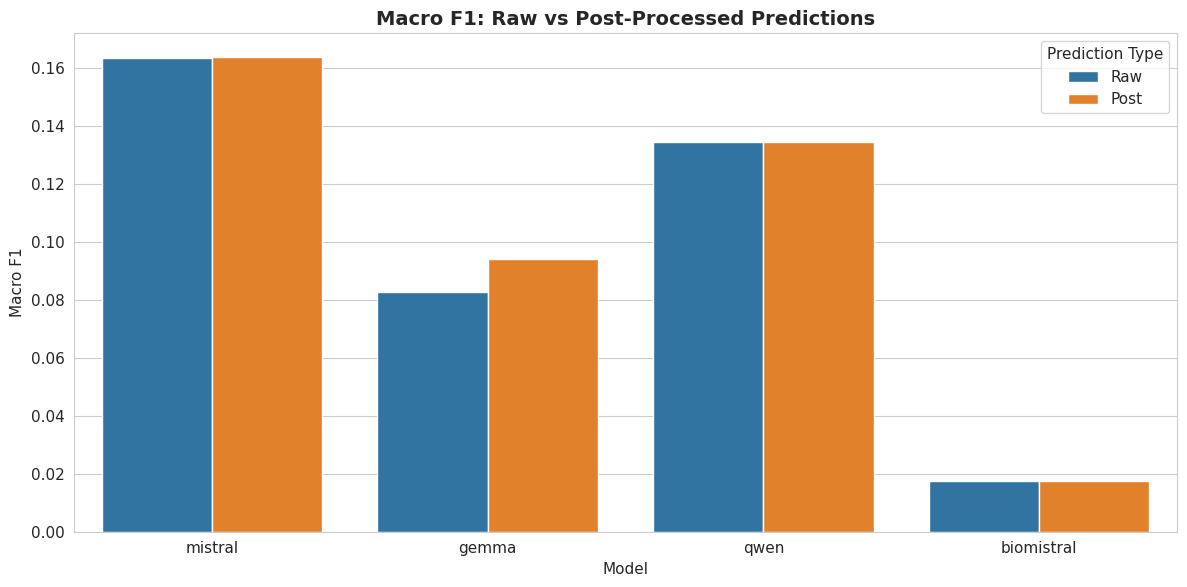

✓ Saved: viz_raw_vs_post_macro_f1.png

PHASE 5B: TOKEN OVERLAP THRESHOLD SENSITIVITY

Evaluating at threshold = 0.5
  MISTRAL | Micro F1: 0.2757
  GEMMA | Micro F1: 0.1581
  QWEN | Micro F1: 0.2500
  BIOMISTRAL | Micro F1: 0.0654

Evaluating at threshold = 0.6
  MISTRAL | Micro F1: 0.1631
  GEMMA | Micro F1: 0.0987
  QWEN | Micro F1: 0.1453
  BIOMISTRAL | Micro F1: 0.0166

Evaluating at threshold = 0.7
  MISTRAL | Micro F1: 0.1351
  GEMMA | Micro F1: 0.0889
  QWEN | Micro F1: 0.1225
  BIOMISTRAL | Micro F1: 0.0113

✓ Saved: threshold_sensitivity_analysis.csv
✓ Saved: viz_threshold_sensitivity.png


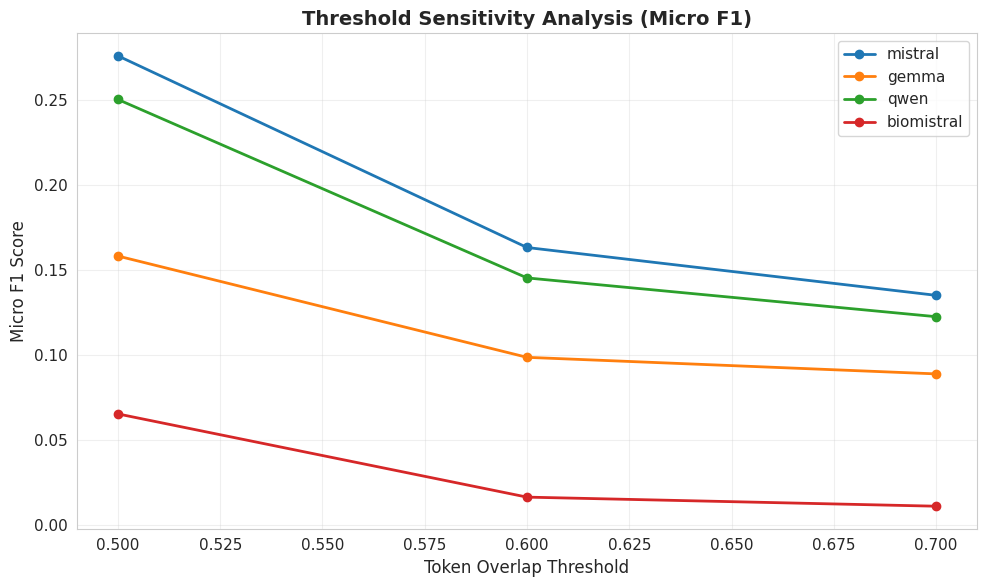

✓ Saved: viz_macro_vs_micro_f1.png


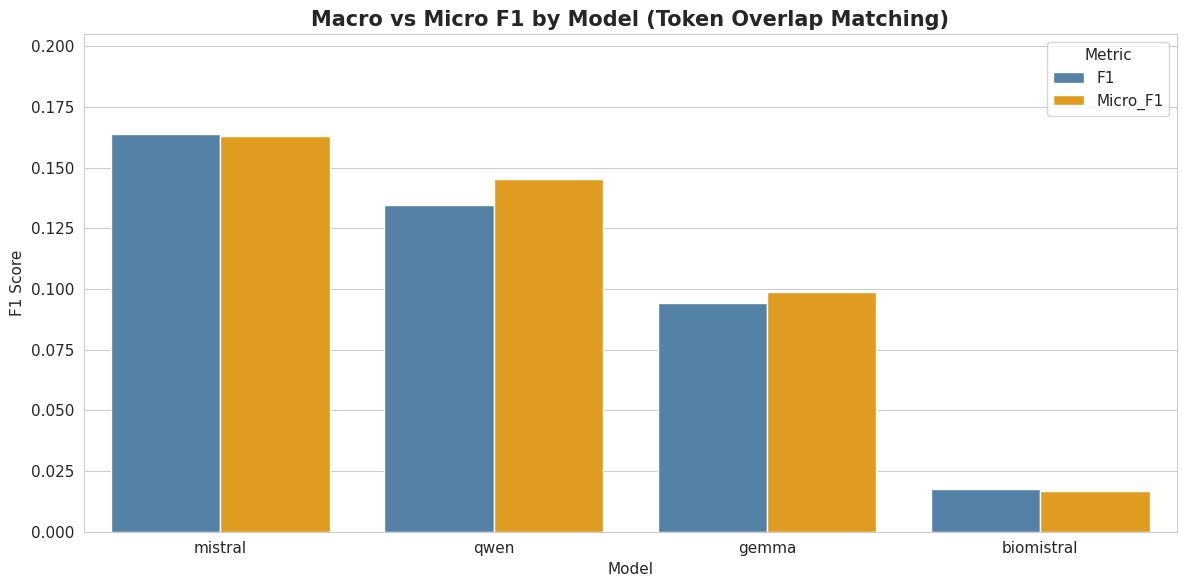

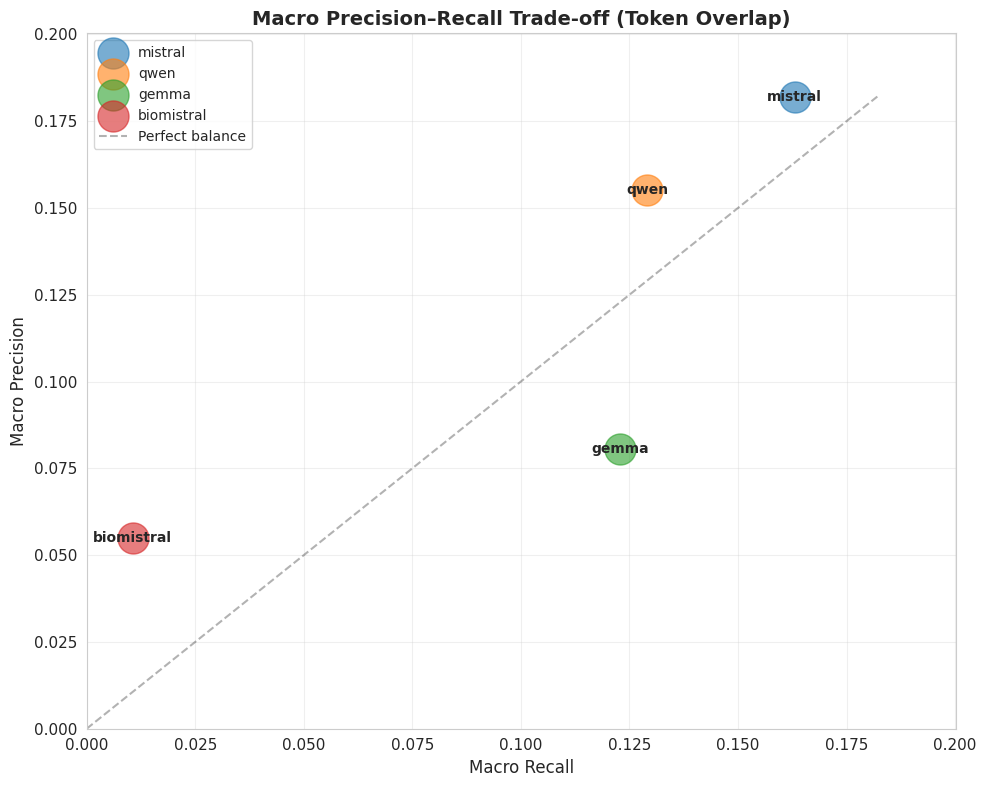

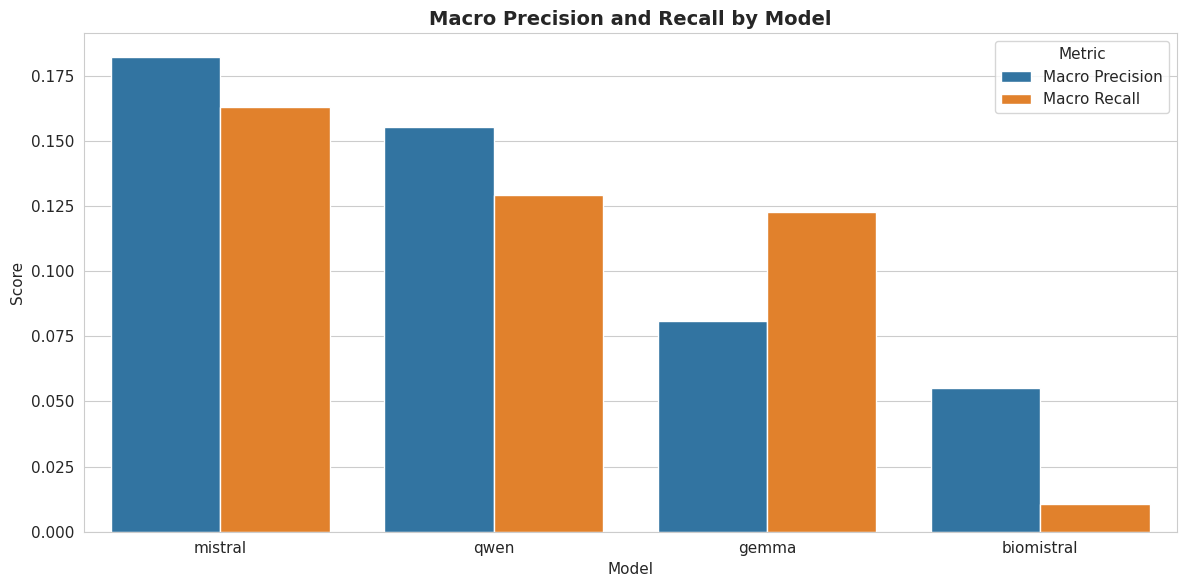

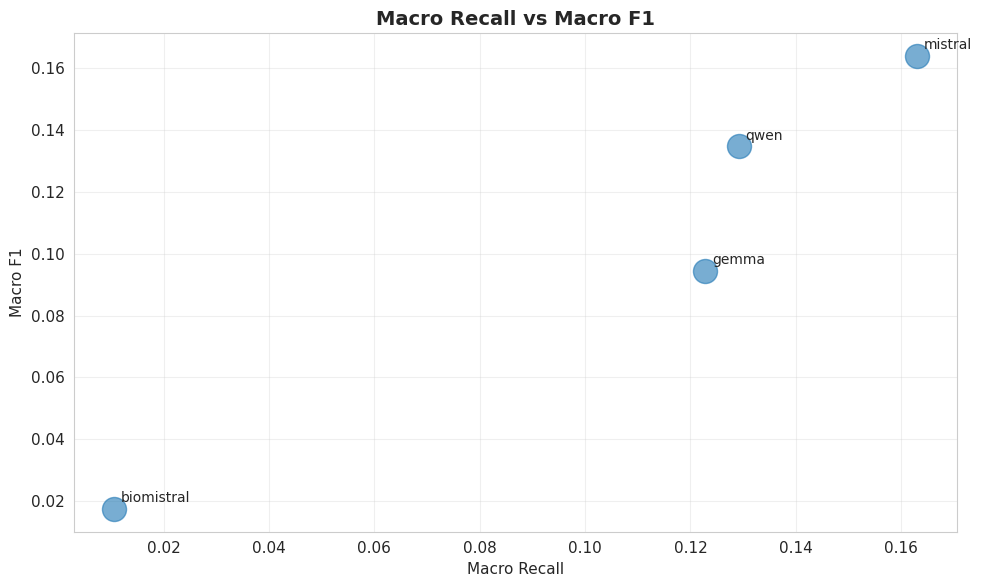


PHASE 5 COMPLETE - Core Metrics Summary (CORRECTED)

📊 CORRECTED RESULTS (Macro & Micro):

     Model  Macro_Precision  Macro_Recall     F1  Micro_Precision  Micro_Recall  Micro_F1
   mistral           0.1821        0.1630 0.1639           0.1700        0.1568    0.1631
      qwen           0.1553        0.1291 0.1347           0.1725        0.1255    0.1453
     gemma           0.0807        0.1228 0.0943           0.0830        0.1217    0.0987
biomistral           0.0550        0.0106 0.0174           0.0742        0.0093    0.0166

✅ Phase 5 Complete: Performance metrics calculated with:
  ✓ Token overlap matching (not substring)
  ✓ Fixed TP double-counting bug
  ✓ Correct precision/recall calculation


In [7]:
"""
CORRECTED NBME EVALUATION - PHASE 5: CORE METRIC COMPUTATION
=============================================================
CRITICAL FIXES:
1. Token overlap matching (not substring)
2. Fixed TP double-counting bug
3. Correct terminology (FP not "hallucination")
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ast

# ============================================================================
# STEP 5.1: DEFINE MATCHING LOGIC (FIXED)
# ============================================================================

print(f"\n{'='*70}")
print("STEP 5.1: Defining Matching Logic (FIXED)")
print(f"{'='*70}")

def normalize(text):
    """Normalize text for matching."""
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

print("✓ Normalization function defined")

# ============================================================================
# FIXED: Token overlap matching instead of substring
# ============================================================================

def token_overlap_match(pred, gold, min_overlap=0.6):
    """
    FIXED: Token overlap matching instead of substring.
    
    Returns True if token overlap >= threshold.
    
    This prevents:
    - "pain" matching "chest pain" 
    - "pressure" matching "blood pressure"
    
    But allows:
    - "chest pain" matching "pain in chest"
    - "difficulty breathing" matching "breathing difficulty"
    """
    pred_norm = normalize(pred)
    gold_norm = normalize(gold)
    
    if not pred_norm or not gold_norm:
        return False
    
    pred_tokens = set(pred_norm.split())
    gold_tokens = set(gold_norm.split())
    
    if not pred_tokens:
        return False
    
    # Calculate overlap from prediction's perspective
    overlap_pred = len(pred_tokens & gold_tokens) / len(pred_tokens)
    overlap_gold = len(pred_tokens & gold_tokens) / len(gold_tokens)

    return min(overlap_pred, overlap_gold) >= min_overlap

print("✓ Token overlap matching function defined (min_overlap=0.6)")

print("\nExample matches:")
test_cases = [
    ("chest pain", "chest pain", True),
    ("chest pain", "pain in chest", True),
    ("pain", "chest pain", False),  # Only 1 token matches, <60%
    ("difficulty breathing", "breathing difficulty", True),
    ("shortness of breath", "dyspnea", False),  # No token overlap
]

for pred, gold, expected in test_cases:
    result = token_overlap_match(pred, gold)
    symbol = "✓" if result == expected else "✗"
    print(f"  {symbol} '{pred}' vs '{gold}': {result}")

# ============================================================================
# STEP 5.2: CALCULATE PER-NOTE METRICS (FIXED)
# ============================================================================

def evaluate_single_note(preds, golds):
    """
    FIXED: Correct TP calculation preventing double-counting.
    
    Each gold symptom can only be matched once.
    Each prediction can only contribute to one TP.
    
    Args:
        preds: List of predicted symptoms
        golds: List of gold standard symptoms
    
    Returns:
        dict with tp, fp, fn, precision, recall, f1
    """
    # Normalize and filter
    preds_norm = [normalize(p) for p in preds if p != 'none']
    preds_norm = [p for p in preds_norm if p]
    
    golds_norm = [normalize(g) for g in golds]
    golds_norm = [g for g in golds_norm if g]
    
    preds_set = set(preds_norm)
    golds_set = set(golds_norm)
    
    # FIXED: Prevent double-counting
    matched_golds = set()
    matched_preds = set()
    tp = 0
    
    # Each prediction tries to match a gold (greedy matching)
    for pred in preds_set:
        for gold in golds_set:
            if gold not in matched_golds and token_overlap_match(pred, gold):
                tp += 1
                matched_golds.add(gold)
                matched_preds.add(pred)
                break  # This prediction matched, move to next
    
    # False Positives = predictions that didn't match any gold
    fp = len(preds_set) - tp
    
    # False Negatives = gold symptoms not matched by any prediction
    fn = len(golds_set) - len(matched_golds)
    
    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

print(f"\n{'='*70}")
print("✓ Per-note evaluation function defined (FIXED)")
print(f"{'='*70}")

# Test the function
print("\nTest case:")
test_preds = ['chest pain', 'difficulty breathing', 'fever']
test_golds = ['chest pain', 'dyspnea']
result = evaluate_single_note(test_preds, test_golds)
print(f"  Predictions: {test_preds}")
print(f"  Gold: {test_golds}")
print(f"  Result: {result}")

# ============================================================================
# LOAD DATA
# ============================================================================

print(f"\n{'='*70}")
print("Loading Data")
print(f"{'='*70}")

# Load post-processed predictions
all_predictions = {}
for model in ["mistral", "gemma", "qwen", "biomistral"]:
    df = pd.read_csv(f"/kaggle/working/{model}_predictions_postprocessed.csv")
    df['predictions'] = df['predictions'].apply(ast.literal_eval)
    all_predictions[model] = df
    print(f"✓ Loaded {model}: {len(df)} notes")

# Load symptom-only gold standard
gold_df = pd.read_csv('/kaggle/working/gold_standard_symptom_only.csv')
gold_df['gold'] = gold_df['gold'].apply(ast.literal_eval)
print(f"✓ Loaded gold standard: {len(gold_df)} notes")

# ============================================================================
# STEP 5.3: EVALUATE ALL MODELS (MACRO + MICRO)
# ============================================================================

print(f"\n{'='*70}")
print("STEP 5.3: Evaluating All Models (Macro + Micro)")
print(f"{'='*70}")

all_results = {}
per_note_results = {}

for model_name, pred_df in all_predictions.items():
    print(f"\nEvaluating {model_name.upper()}...")
    
    merged = pred_df.merge(gold_df, on='pn_num', how='inner')
    print(f"  Matched {len(merged)} notes")
    
    results = []
    for _, row in merged.iterrows():
        metrics = evaluate_single_note(row['predictions'], row['gold'])
        metrics['pn_num'] = row['pn_num']
        results.append(metrics)
    
    results_df = pd.DataFrame(results)
    per_note_results[model_name] = results_df
    
    # ==========================
    # MACRO METRICS (per-note mean)
    # ==========================
    macro_precision = results_df['precision'].mean()
    macro_recall = results_df['recall'].mean()
    macro_f1 = results_df['f1'].mean()
    
    # ==========================
    # MICRO METRICS (global TP/FP/FN)
    # ==========================
    total_tp = results_df['tp'].sum()
    total_fp = results_df['fp'].sum()
    total_fn = results_df['fn'].sum()
    
    micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    micro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    micro_f1 = (
        2 * micro_precision * micro_recall / (micro_precision + micro_recall)
        if (micro_precision + micro_recall) > 0 else 0
    )
    
    all_results[model_name] = {
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
        'micro_precision': micro_precision,
        'micro_recall': micro_recall,
        'micro_f1': micro_f1,
        'total_tp': total_tp,
        'total_fp': total_fp,
        'total_fn': total_fn,
    }
    
    print(f"  Macro F1: {macro_f1:.4f}")
    print(f"  Micro F1: {micro_f1:.4f}")
    print(f"  Total TP: {total_tp}")
    print(f"  Total FP: {total_fp}")
    print(f"  Total FN: {total_fn}")
    
    results_df.to_csv(f'/kaggle/working/{model_name}_per_note_metrics.csv', index=False)

# ============================================================================
# STEP 5.4: CREATE SUMMARY TABLE (MACRO + MICRO)
# ============================================================================

summary_data = []

for model_name, metrics in all_results.items():
    summary_data.append({
        'Model': model_name,
        'Macro_Precision': metrics['macro_precision'],
        'Macro_Recall': metrics['macro_recall'],
        'F1': metrics['macro_f1'],  # Keep name for compatibility
        'Micro_Precision': metrics['micro_precision'],
        'Micro_Recall': metrics['micro_recall'],
        'Micro_F1': metrics['micro_f1'],
        'TP': metrics['total_tp'],
        'FP': metrics['total_fp'],
        'FN': metrics['total_fn']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('F1', ascending=False).reset_index(drop=True)

print("\n", summary_df.to_string(index=False))

summary_df.to_csv('/kaggle/working/model_performance_summary.csv', index=False)
print("\n✓ Saved: model_performance_summary.csv")

# ============================================================================
# PHASE 5A: RAW vs POST-PROCESSED PERFORMANCE COMPARISON
# ============================================================================

print(f"\n{'='*80}")
print("PHASE 5A: RAW vs POST-PROCESSED PERFORMANCE")
print(f"{'='*80}")

raw_vs_post_results = []

for model in ["mistral", "gemma", "qwen", "biomistral"]:
    
    print(f"\nEvaluating RAW vs POST for {model.upper()}...")
    
    # Load RAW predictions
    raw_df = pd.read_csv(f"/kaggle/working/{model}_predictions_raw_clean.csv")
    raw_df['predictions'] = raw_df['predictions'].apply(ast.literal_eval)
    
    # Load POST predictions
    post_df = pd.read_csv(f"/kaggle/working/{model}_predictions_postprocessed.csv")
    post_df['predictions'] = post_df['predictions'].apply(ast.literal_eval)
    
    # Merge with gold
    raw_merged = raw_df.merge(gold_df, on='pn_num', how='inner')
    post_merged = post_df.merge(gold_df, on='pn_num', how='inner')
    
    # Evaluate RAW
    raw_metrics = []
    for _, row in raw_merged.iterrows():
        raw_metrics.append(evaluate_single_note(row['predictions'], row['gold']))
    raw_metrics_df = pd.DataFrame(raw_metrics)
    
    # Evaluate POST
    post_metrics = []
    for _, row in post_merged.iterrows():
        post_metrics.append(evaluate_single_note(row['predictions'], row['gold']))
    post_metrics_df = pd.DataFrame(post_metrics)
    
    # Macro F1
    raw_macro_f1 = raw_metrics_df['f1'].mean()
    post_macro_f1 = post_metrics_df['f1'].mean()
    
    # Micro F1
    raw_tp = raw_metrics_df['tp'].sum()
    raw_fp = raw_metrics_df['fp'].sum()
    raw_fn = raw_metrics_df['fn'].sum()
    
    post_tp = post_metrics_df['tp'].sum()
    post_fp = post_metrics_df['fp'].sum()
    post_fn = post_metrics_df['fn'].sum()
    
    raw_micro_precision = raw_tp / (raw_tp + raw_fp) if (raw_tp + raw_fp) > 0 else 0
    raw_micro_recall = raw_tp / (raw_tp + raw_fn) if (raw_tp + raw_fn) > 0 else 0
    raw_micro_f1 = (
        2 * raw_micro_precision * raw_micro_recall / (raw_micro_precision + raw_micro_recall)
        if (raw_micro_precision + raw_micro_recall) > 0 else 0
    )
    
    post_micro_precision = post_tp / (post_tp + post_fp) if (post_tp + post_fp) > 0 else 0
    post_micro_recall = post_tp / (post_tp + post_fn) if (post_tp + post_fn) > 0 else 0
    post_micro_f1 = (
        2 * post_micro_precision * post_micro_recall / (post_micro_precision + post_micro_recall)
        if (post_micro_precision + post_micro_recall) > 0 else 0
    )
    
    raw_vs_post_results.append({
        'Model': model,
        'Raw Macro F1': raw_macro_f1,
        'Post Macro F1': post_macro_f1,
        'Raw Micro F1': raw_micro_f1,
        'Post Micro F1': post_micro_f1,
        'Macro Δ': post_macro_f1 - raw_macro_f1,
        'Micro Δ': post_micro_f1 - raw_micro_f1
    })
    
    print(f"  Raw Macro F1:  {raw_macro_f1:.4f}")
    print(f"  Post Macro F1: {post_macro_f1:.4f}")
    print(f"  Raw Micro F1:  {raw_micro_f1:.4f}")
    print(f"  Post Micro F1: {post_micro_f1:.4f}")

raw_post_df = pd.DataFrame(raw_vs_post_results)
raw_post_df.to_csv('/kaggle/working/raw_vs_post_performance.csv', index=False)

print("\n✓ Saved: raw_vs_post_performance.csv")
print("\n", raw_post_df.to_string(index=False))

# ============================================================================
# VISUALIZATION: RAW vs POST F1 Comparison
# ============================================================================

plot_data = []

for _, row in raw_post_df.iterrows():
    plot_data.append({'Model': row['Model'], 'Version': 'Raw', 'Macro F1': row['Raw Macro F1']})
    plot_data.append({'Model': row['Model'], 'Version': 'Post', 'Macro F1': row['Post Macro F1']})

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='Model', y='Macro F1', hue='Version')
plt.title('Macro F1: Raw vs Post-Processed Predictions', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Macro F1')
plt.legend(title='Prediction Type')

plt.tight_layout()
plt.savefig('/kaggle/working/viz_raw_vs_post_macro_f1.png', dpi=300)
plt.show()

print("✓ Saved: viz_raw_vs_post_macro_f1.png")

# ============================================================================
# PHASE 5B: THRESHOLD SENSITIVITY ANALYSIS (50% / 60% / 70%)
# ============================================================================

print(f"\n{'='*80}")
print("PHASE 5B: TOKEN OVERLAP THRESHOLD SENSITIVITY")
print(f"{'='*80}")

thresholds = [0.5, 0.6, 0.7]
sensitivity_results = []

def evaluate_with_threshold(preds, golds, threshold):
    preds_norm = [normalize(p) for p in preds if p != 'none']
    preds_norm = [p for p in preds_norm if p]
    golds_norm = [normalize(g) for g in golds]
    golds_norm = [g for g in golds_norm if g]
    
    preds_set = set(preds_norm)
    golds_set = set(golds_norm)
    
    matched_golds = set()
    tp = 0
    
    for pred in preds_set:
        for gold in golds_set:
            if gold not in matched_golds and token_overlap_match(pred, gold, min_overlap=threshold):
                tp += 1
                matched_golds.add(gold)
                break
    
    fp = len(preds_set) - tp
    fn = len(golds_set) - len(matched_golds)
    
    return tp, fp, fn


for threshold in thresholds:
    print(f"\nEvaluating at threshold = {threshold}")
    
    for model_name, pred_df in all_predictions.items():
        
        merged = pred_df.merge(gold_df, on='pn_num', how='inner')
        
        total_tp, total_fp, total_fn = 0, 0, 0
        
        for _, row in merged.iterrows():
            tp, fp, fn = evaluate_with_threshold(
                row['predictions'], 
                row['gold'], 
                threshold
            )
            total_tp += tp
            total_fp += fp
            total_fn += fn
        
        micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
        micro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
        micro_f1 = (
            2 * micro_precision * micro_recall / (micro_precision + micro_recall)
            if (micro_precision + micro_recall) > 0 else 0
        )
        
        sensitivity_results.append({
            'Model': model_name,
            'Threshold': threshold,
            'Micro_Precision': micro_precision,
            'Micro_Recall': micro_recall,
            'Micro_F1': micro_f1
        })
        
        print(f"  {model_name.upper()} | Micro F1: {micro_f1:.4f}")

# Convert to DataFrame
sensitivity_df = pd.DataFrame(sensitivity_results)

# Save for paper
sensitivity_df.to_csv('/kaggle/working/threshold_sensitivity_analysis.csv', index=False)
print("\n✓ Saved: threshold_sensitivity_analysis.csv")

# ============================================================================
# VISUALIZATION: Threshold vs Micro F1
# ============================================================================

plt.figure(figsize=(10, 6))

for model in sensitivity_df['Model'].unique():
    model_data = sensitivity_df[sensitivity_df['Model'] == model]
    plt.plot(
        model_data['Threshold'],
        model_data['Micro_F1'],
        marker='o',
        linewidth=2,
        label=model
    )

plt.xlabel('Token Overlap Threshold', fontsize=12)
plt.ylabel('Micro F1 Score', fontsize=12)
plt.title('Threshold Sensitivity Analysis (Micro F1)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/viz_threshold_sensitivity.png', dpi=300)
print("✓ Saved: viz_threshold_sensitivity.png")
plt.show()

# ============================================================================
# VISUALIZATIONS (same as before, but with corrected data)
# ============================================================================

# ============================================================================
# VIZ 7: Macro vs Micro F1 Comparison
# ============================================================================

plt.figure(figsize=(12, 6))

plot_df = summary_df.melt(
    id_vars='Model',
    value_vars=['F1', 'Micro_F1'],
    var_name='Metric',
    value_name='Score'
)

sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', palette=['steelblue', 'orange'])

plt.title('Macro vs Micro F1 by Model (Token Overlap Matching)', fontsize=15, fontweight='bold')
plt.ylabel('F1 Score')
plt.xlabel('Model')

plt.ylim(0, max(plot_df['Score']) * 1.25)
plt.legend(title='Metric')

plt.tight_layout()
plt.savefig('/kaggle/working/viz_macro_vs_micro_f1.png', dpi=300)
print("✓ Saved: viz_macro_vs_micro_f1.png")
plt.show()

# VIZ 8: Macro Precision vs Macro Recall
plt.figure(figsize=(10, 8))

for _, row in summary_df.iterrows():
    plt.scatter(row['Macro_Recall'], row['Macro_Precision'], 
                s=500, alpha=0.6, label=row['Model'])
    plt.annotate(row['Model'], 
                 (row['Macro_Recall'], row['Macro_Precision']), 
                 ha='center', va='center', fontweight='bold', fontsize=10)

max_val = max(summary_df['Macro_Precision'].max(), 
              summary_df['Macro_Recall'].max())

plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Perfect balance')

plt.xlabel('Macro Recall', fontsize=12)
plt.ylabel('Macro Precision', fontsize=12)
plt.title('Macro Precision–Recall Trade-off (Token Overlap)', 
          fontsize=14, fontweight='bold')

plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0, max_val * 1.1)
plt.ylim(0, max_val * 1.1)

plt.tight_layout()
plt.savefig('/kaggle/working/viz_08_precision_recall_tradeoff_corrected.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# VIZ 9: Macro Precision and Recall
plot_data = []

for _, row in summary_df.iterrows():
    plot_data.append({'Model': row['Model'], 
                      'Metric': 'Macro Precision', 
                      'Score': row['Macro_Precision']})
    plot_data.append({'Model': row['Model'], 
                      'Metric': 'Macro Recall', 
                      'Score': row['Macro_Recall']})

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric')

plt.title('Macro Precision and Recall by Model', 
          fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Score')

plt.tight_layout()
plt.savefig('/kaggle/working/viz_09_macro_precision_recall.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# VIZ 10: Macro Recall vs Macro F1
plt.figure(figsize=(10, 6))

plt.scatter(summary_df['Macro_Recall'], 
            summary_df['F1'], 
            s=300, alpha=0.6)

for _, row in summary_df.iterrows():
    plt.annotate(row['Model'], 
                 (row['Macro_Recall'], row['F1']),
                 xytext=(5, 5),
                 textcoords='offset points',
                 fontsize=10)

plt.xlabel('Macro Recall')
plt.ylabel('Macro F1')
plt.title('Macro Recall vs Macro F1', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/viz_10_recall_vs_f1_corrected.png',
            dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("PHASE 5 COMPLETE - Core Metrics Summary (CORRECTED)")
print(f"{'='*70}")

print("\n📊 CORRECTED RESULTS (Macro & Micro):\n")

display_cols = [
    'Model',
    'Macro_Precision',
    'Macro_Recall',
    'F1',
    'Micro_Precision',
    'Micro_Recall',
    'Micro_F1'
]

print(summary_df[display_cols].round(4).to_string(index=False))

print("\n✅ Phase 5 Complete: Performance metrics calculated with:")
print("  ✓ Token overlap matching (not substring)")
print("  ✓ Fixed TP double-counting bug")
print("  ✓ Correct precision/recall calculation")


STEP 6.1: Extracting All Errors (CORRECTED TAXONOMY)

Extracting errors for MISTRAL...
  False Positives: 4003
  False Negatives: 4467
  Total errors: 8470

Extracting errors for GEMMA...
  False Positives: 7604
  False Negatives: 4806
  Total errors: 12410

Extracting errors for QWEN...
  False Positives: 3101
  False Negatives: 4735
  Total errors: 7836

Extracting errors for BIOMISTRAL...
  False Positives: 558
  False Negatives: 5803
  Total errors: 6361

Total errors extracted: 35,077

STEP 6.2: Categorizing Errors (IMPROVED)
✓ Errors categorized with improved taxonomy

Category distribution:
  boundary_mismatch: 12,210 (34.8%)
  complex_phrasing: 11,294 (32.2%)
  other: 10,191 (29.1%)
  negation_error: 723 (2.1%)
  over_generalization: 451 (1.3%)
  generic_term: 128 (0.4%)
  annotation_issue: 80 (0.2%)

STEP 6.3: Error Distribution by Model

      Model  FP Count  FN Count   Total  FP %  FN %
biomistral    5803.0     558.0  6361.0   8.8  91.2
     gemma    4806.0    7604.0 12410

<Figure size 1200x600 with 0 Axes>

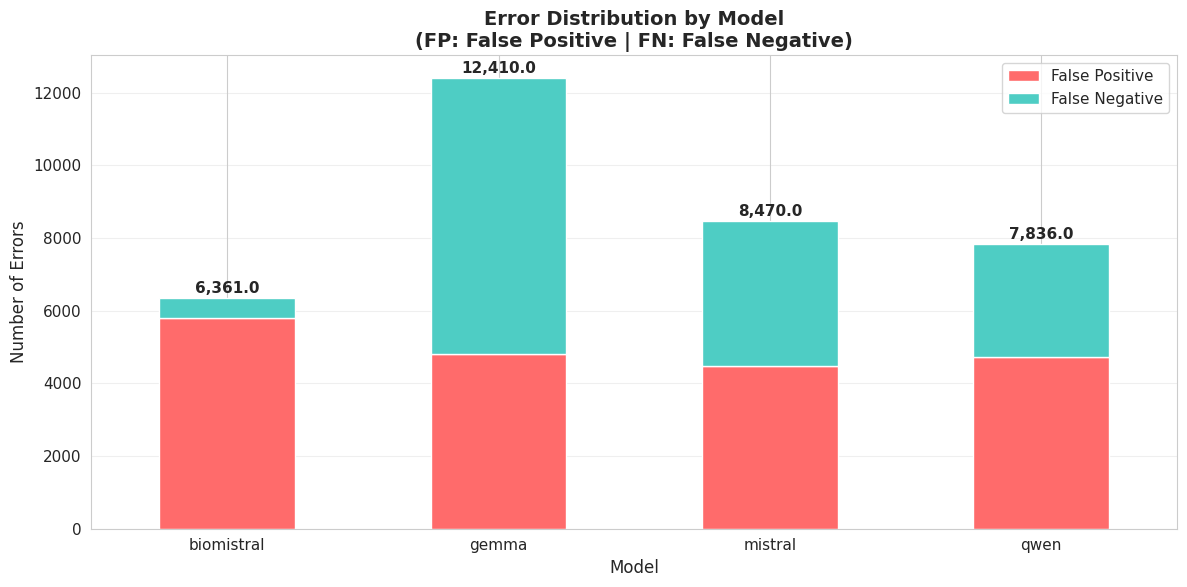

✓ Saved: viz_12_error_category_heatmap_corrected.png


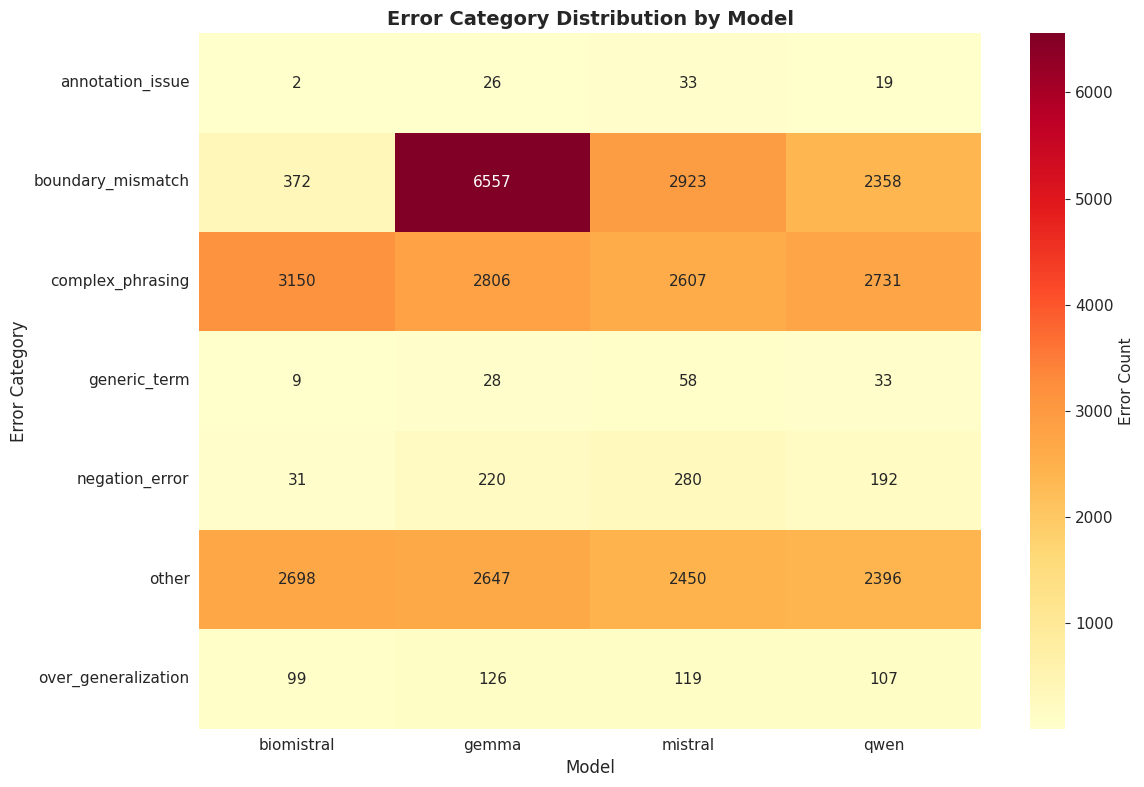

✓ Saved: viz_13_error_category_pies_corrected.png


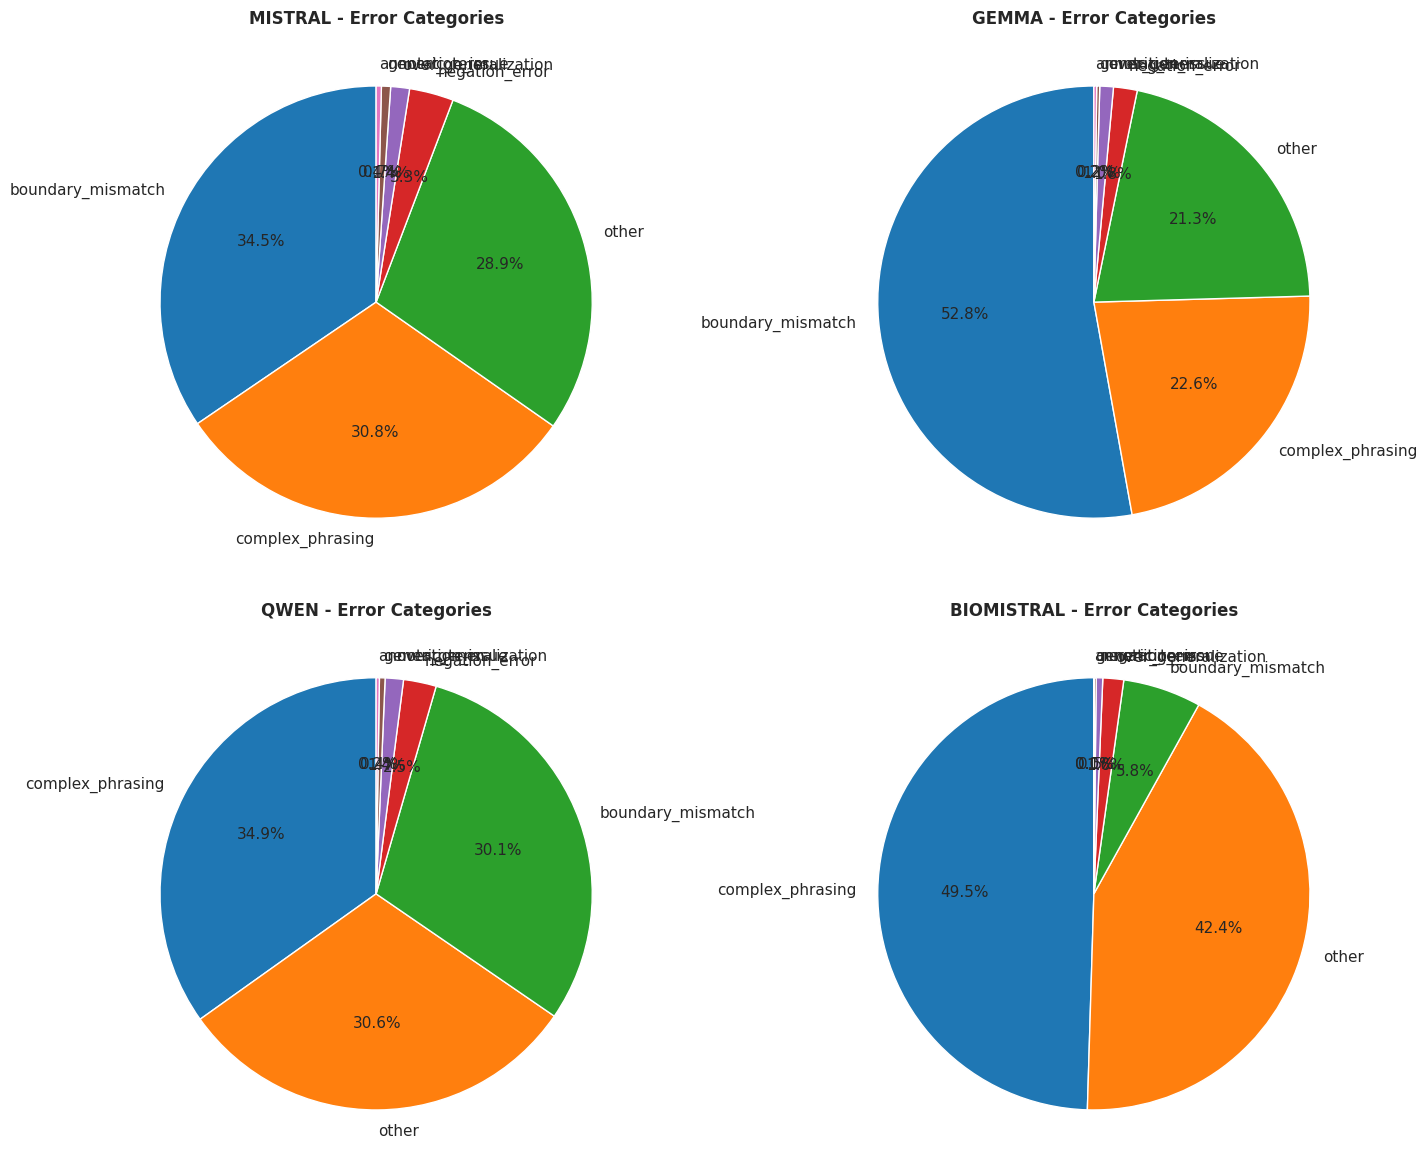


PHASE 6 COMPLETE - Error Analysis Summary (CORRECTED)

📊 Total Errors: 35,077

Breakdown:
  false_positive: 15,266 (43.5%)
  false_negative: 19,811 (56.5%)

✅ Phase 6 Complete: Error analysis with correct taxonomy


In [8]:
"""
CORRECTED NBME EVALUATION - PHASE 6: ERROR ANALYSIS
====================================================
CRITICAL FIX: Correct error taxonomy (not just FP=hallucination, FN=missed)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ast
from collections import Counter

# ============================================================================
# STEP 6.1: EXTRACT ALL ERRORS (FIXED TERMINOLOGY)
# ============================================================================

print(f"\n{'='*70}")
print("STEP 6.1: Extracting All Errors (CORRECTED TAXONOMY)")
print(f"{'='*70}")

def normalize(text):
    """Normalize text for comparison."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def token_overlap_match(pred, gold, min_overlap=0.6):
    """Token overlap matching (same as Phase 5)."""
    pred_norm = normalize(pred)
    gold_norm = normalize(gold)
    
    if not pred_norm or not gold_norm:
        return False
    
    pred_tokens = set(pred_norm.split())
    gold_tokens = set(gold_norm.split())
    
    if not pred_tokens:
        return False
    
    overlap = len(pred_tokens & gold_tokens) / len(pred_tokens)
    return overlap >= min_overlap

def extract_errors_from_note(pn_num, preds, golds, model_name):
    """
    FIXED: Extract errors with correct classification.
    
    Error types:
    - false_positive: Predicted but not in gold
    - false_negative: In gold but not predicted
    
    We do NOT call these "hallucinations" or "missed" at this stage.
    Detailed categorization comes later.
    """
    errors = []
    
    # Normalize
    preds_norm = [normalize(p) for p in preds if p != 'none']
    preds_norm = [p for p in preds_norm if p]
    
    golds_norm = [normalize(g) for g in golds]
    golds_norm = [g for g in golds_norm if g]
    
    preds_set = set(preds_norm)
    golds_set = set(golds_norm)
    
    # Track matched items (same logic as evaluation)
    matched_golds = set()
    matched_preds = set()
    
    for pred in preds_set:
        for gold in golds_set:
            if gold not in matched_golds and token_overlap_match(pred, gold):
                matched_golds.add(gold)
                matched_preds.add(pred)
                break
    
    # False Positives = predictions not matched
    for pred in preds_set:
        if pred not in matched_preds:
            errors.append({
                'model': model_name,
                'pn_num': pn_num,
                'error_type': 'false_positive',
                'text': pred,
                'gold_context': str(golds)[:100]
            })
    
    # False Negatives = golds not matched
    for gold in golds_set:
        if gold not in matched_golds:
            errors.append({
                'model': model_name,
                'pn_num': pn_num,
                'error_type': 'false_negative',
                'text': gold,
                'pred_context': str(preds)[:100]
            })
    
    return errors

# Load data
all_predictions = {}
for model in ["mistral", "gemma", "qwen", "biomistral"]:
    df = pd.read_csv(f"/kaggle/working/{model}_predictions_postprocessed.csv")
    df['predictions'] = df['predictions'].apply(ast.literal_eval)
    all_predictions[model] = df

gold_df = pd.read_csv('/kaggle/working/gold_standard_symptom_only.csv')
gold_df['gold'] = gold_df['gold'].apply(ast.literal_eval)

# Extract errors
all_errors = []

for model_name, pred_df in all_predictions.items():
    print(f"\nExtracting errors for {model_name.upper()}...")
    
    merged = pred_df.merge(gold_df, on='pn_num', how='inner')
    
    for _, row in merged.iterrows():
        note_errors = extract_errors_from_note(
            row['pn_num'], 
            row['predictions'], 
            row['gold'], 
            model_name
        )
        all_errors.extend(note_errors)
    
    model_errors = [e for e in all_errors if e['model'] == model_name]
    fp_count = sum(1 for e in model_errors if e['error_type'] == 'false_positive')
    fn_count = sum(1 for e in model_errors if e['error_type'] == 'false_negative')
    
    print(f"  False Positives: {fp_count}")
    print(f"  False Negatives: {fn_count}")
    print(f"  Total errors: {len(model_errors)}")

errors_df = pd.DataFrame(all_errors)

print(f"\n{'='*70}")
print(f"Total errors extracted: {len(errors_df):,}")
print(f"{'='*70}")

# ============================================================================
# STEP 6.2: CATEGORIZE ERRORS (IMPROVED TAXONOMY)
# ============================================================================

print(f"\n{'='*70}")
print("STEP 6.2: Categorizing Errors (IMPROVED)")
print(f"{'='*70}")

def categorize_error(error_text, error_type):
    """
    FIXED: Better error taxonomy.
    
    Categories:
    - over_generalization: Generic term (e.g., "pain" alone)
    - boundary_mismatch: Partially correct (e.g., "chest pain" vs "pain in chest")
    - annotation_issue: Family/history extracted
    - negation_error: Negated symptom extracted
    - complex_phrasing: Embedded in complex sentence
    - other: Uncategorized
    """
    text_lower = error_text.lower()
    
    # Over-generalization (single-word generic)
    single_word_generic = ['pain', 'ache', 'discomfort', 'pressure', 'weakness', 
                           'fatigue', 'swelling', 'redness']
    if text_lower in single_word_generic:
        return 'over_generalization'
    
    # Annotation issues
    if any(keyword in text_lower for keyword in ['family', 'father', 'mother', 'history']):
        return 'annotation_issue'
    
    # Negation
    if any(keyword in text_lower for keyword in ['denies', 'no ', 'without', 'negative for']):
        return 'negation_error'
    
    # Complex phrasing
    complex_indicators = ['associated with', 'related to', 'accompanied by', 'context of']
    if any(indicator in text_lower for indicator in complex_indicators):
        return 'complex_phrasing'
    
    # Generic/vague
    if any(pattern in text_lower for pattern in ['general', 'mild', 'moderate', 'severe']):
        return 'generic_term'
    
    # Boundary mismatch (multi-word, likely partial match)
    if len(text_lower.split()) > 1 and error_type == 'false_positive':
        return 'boundary_mismatch'
    
    if len(text_lower.split()) > 2 and error_type == 'false_negative':
        return 'complex_phrasing'
    
    return 'other'

errors_df['category'] = errors_df.apply(
    lambda row: categorize_error(row['text'], row['error_type']),
    axis=1
)

print("✓ Errors categorized with improved taxonomy")

print("\nCategory distribution:")
category_counts = errors_df['category'].value_counts()
for category, count in category_counts.items():
    pct = (count / len(errors_df)) * 100
    print(f"  {category}: {count:,} ({pct:.1f}%)")

# ============================================================================
# STEP 6.3: MODEL-LEVEL ERROR SUMMARY
# ============================================================================

print(f"\n{'='*70}")
print("STEP 6.3: Error Distribution by Model")
print(f"{'='*70}")

model_summary = errors_df.groupby(['model', 'error_type']).size().reset_index(name='count')
model_pivot = model_summary.pivot_table(
    index='model',
    columns='error_type',
    values='count',
    fill_value=0
).reset_index()

model_pivot['total'] = model_pivot['false_positive'] + model_pivot['false_negative']
model_pivot['fp_pct'] = (model_pivot['false_positive'] / model_pivot['total'] * 100).round(1)
model_pivot['fn_pct'] = (model_pivot['false_negative'] / model_pivot['total'] * 100).round(1)

# FIXED: Rename columns to avoid confusion
model_pivot.columns = ['Model', 'FP Count', 'FN Count', 'Total', 'FP %', 'FN %']

print("\n", model_pivot.to_string(index=False))

# ============================================================================
# STEP 6.4: SELECT REPRESENTATIVE EXAMPLES
# ============================================================================

print(f"\n{'='*70}")
print("STEP 6.4: Selecting Representative Examples")
print(f"{'='*70}")

examples = []

for category in errors_df['category'].unique():
    for error_type in ['false_positive', 'false_negative']:
        category_errors = errors_df[
            (errors_df['category'] == category) & 
            (errors_df['error_type'] == error_type)
        ]
        
        if len(category_errors) > 0:
            samples = category_errors.sample(min(2, len(category_errors)), random_state=42)
            examples.append(samples)

if examples:
    examples_df = pd.concat(examples, ignore_index=True)
    examples_df.to_csv('/kaggle/working/nbme_error_examples_for_paper.csv', index=False)
    print(f"✓ Saved {len(examples_df)} representative examples")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print(f"\n{'='*70}")
print("Creating Error Analysis Visualizations...")
print(f"{'='*70}")

# VIZ 11: Error Type Distribution
plt.figure(figsize=(12, 6))

plot_data = model_pivot[['Model', 'FP Count', 'FN Count']].set_index('Model')
plot_data.plot(kind='bar', stacked=True, color=['#ff6b6b', '#4ecdc4'], figsize=(12, 6))
plt.title('Error Distribution by Model\n(FP: False Positive | FN: False Negative)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Number of Errors', fontsize=12)
plt.legend(['False Positive', 'False Negative'], fontsize=11, loc='upper right')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

for i, (idx, row) in enumerate(model_pivot.iterrows()):
    plt.text(i, row['Total'] + 50, f"{row['Total']:,}", 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/viz_11_error_type_distribution_corrected.png', dpi=300, bbox_inches='tight')
print("✓ Saved: viz_11_error_type_distribution_corrected.png")
plt.show()

# VIZ 12: Error Category Heatmap
heatmap_data = errors_df.groupby(['model', 'category']).size().reset_index(name='count')
heatmap_pivot = heatmap_data.pivot(index='category', columns='model', values='count').fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_pivot, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Error Count'})
plt.title('Error Category Distribution by Model', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Error Category', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/viz_12_error_category_heatmap_corrected.png', dpi=300, bbox_inches='tight')
print("✓ Saved: viz_12_error_category_heatmap_corrected.png")
plt.show()

# VIZ 13: Category Pie Charts
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, model in enumerate(['mistral', 'gemma', 'qwen', 'biomistral']):
    model_errors = errors_df[errors_df['model'] == model]
    category_counts = model_errors['category'].value_counts()
    
    axes[idx].pie(category_counts.values, labels=category_counts.index, 
                  autopct='%1.1f%%', startangle=90)
    axes[idx].set_title(f'{model.upper()} - Error Categories', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/viz_13_error_category_pies_corrected.png', dpi=300, bbox_inches='tight')
print("✓ Saved: viz_13_error_category_pies_corrected.png")
plt.show()

# ============================================================================
# SAVE OUTPUTS
# ============================================================================

errors_df.to_csv('/kaggle/working/nbme_all_errors_corrected.csv', index=False)
model_pivot.to_csv('/kaggle/working/nbme_error_model_summary_corrected.csv', index=False)

print(f"\n{'='*70}")
print("PHASE 6 COMPLETE - Error Analysis Summary (CORRECTED)")
print(f"{'='*70}")

print(f"\n📊 Total Errors: {len(errors_df):,}")
print(f"\nBreakdown:")
for error_type in ['false_positive', 'false_negative']:
    count = (errors_df['error_type'] == error_type).sum()
    pct = (count / len(errors_df)) * 100
    print(f"  {error_type}: {count:,} ({pct:.1f}%)")

print("\n✅ Phase 6 Complete: Error analysis with correct taxonomy")

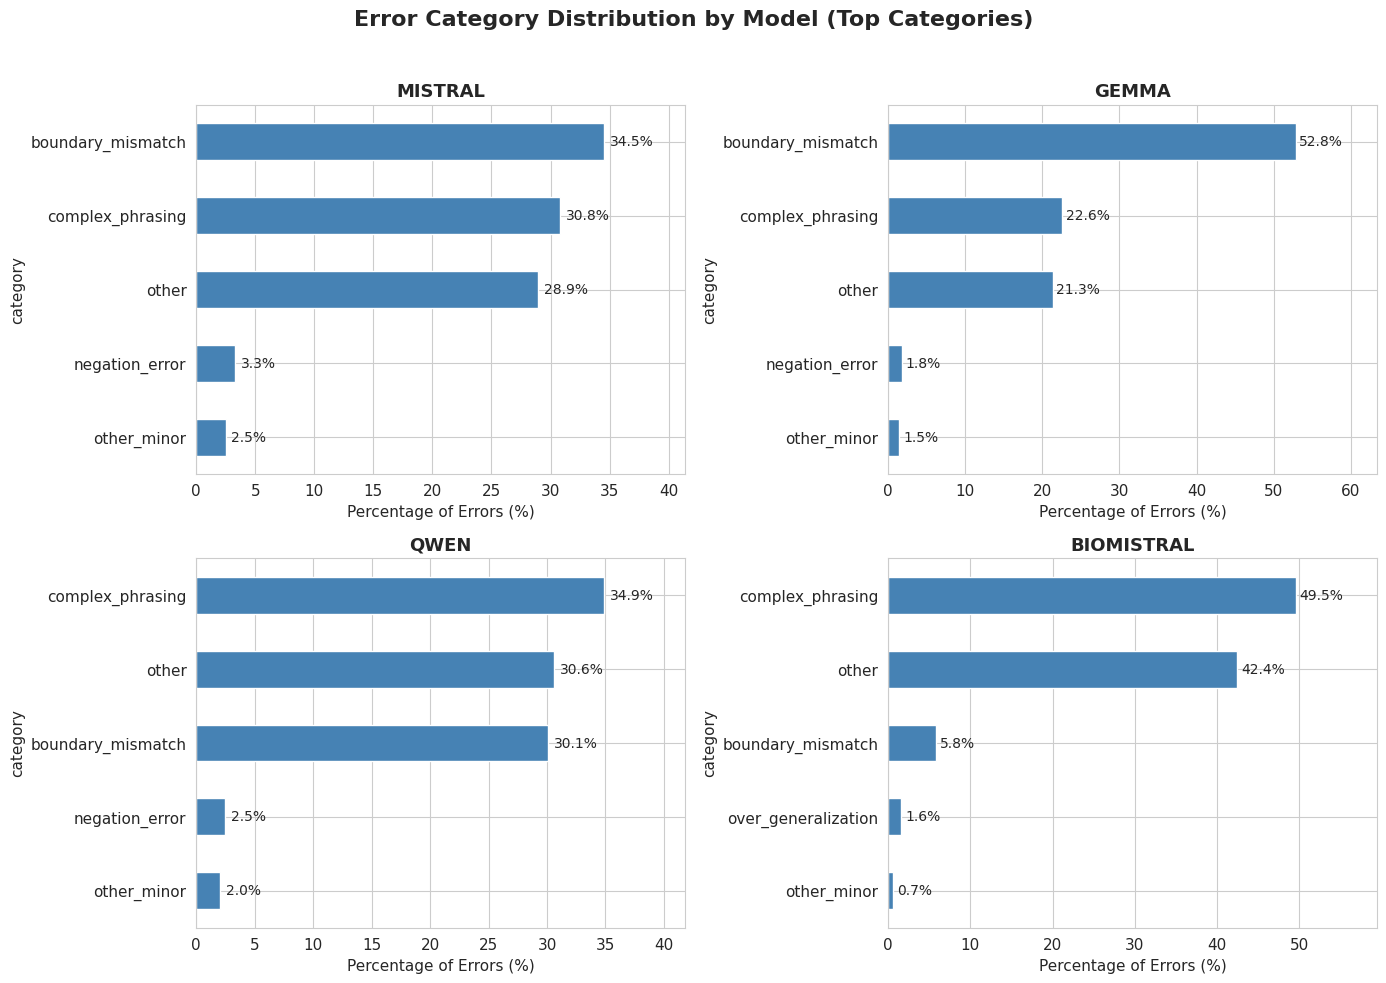

✓ Saved: viz_error_categories_small_multiples.png


In [9]:
# ============================================================
# FIXED VISUALIZATION: Small-Multiple Bar Charts (Reviewer-Safe)
# ============================================================

import matplotlib.pyplot as plt

TOP_K = 4
models = ['mistral', 'gemma', 'qwen', 'biomistral']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, model in enumerate(models):
    ax = axes[idx]
    
    model_errors = errors_df[errors_df['model'] == model]
    counts = model_errors['category'].value_counts(normalize=True) * 100
    
    top = counts.head(TOP_K)
    rest = counts.iloc[TOP_K:].sum()
    
    if rest > 0:
        top['other_minor'] = rest
    
    top.sort_values(ascending=True).plot(
    kind='barh',
    ax=ax,
    color='steelblue'
    )

    ax.set_title(model.upper(), fontsize=13, fontweight='bold')
    ax.set_xlabel('Percentage of Errors (%)')
    ax.set_xlim(0, max(top.values) * 1.2)

    # ✅ Correct annotation logic
    for bar in ax.patches:
        width = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        ax.text(width + 0.5, y, f"{width:.1f}%", va='center', fontsize=10)

plt.suptitle(
    'Error Category Distribution by Model (Top Categories)',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(
    '/kaggle/working/viz_error_categories_small_multiples.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print("✓ Saved: viz_error_categories_small_multiples.png")


PHASE 7: MODEL-SPECIFIC DEEP DIVES

--------------------------------------------------------------------------------
STEP 7.1: BioMistral Failure Analysis
--------------------------------------------------------------------------------

🔍 BioMistral Deep Dive:
  Mean symptoms: 1.01
  Median symptoms: 1
  Empty predictions: 0 (0.0%)
  Mean F1: 0.0174

✓ Saved: viz_15_biomistral_analysis_corrected.png


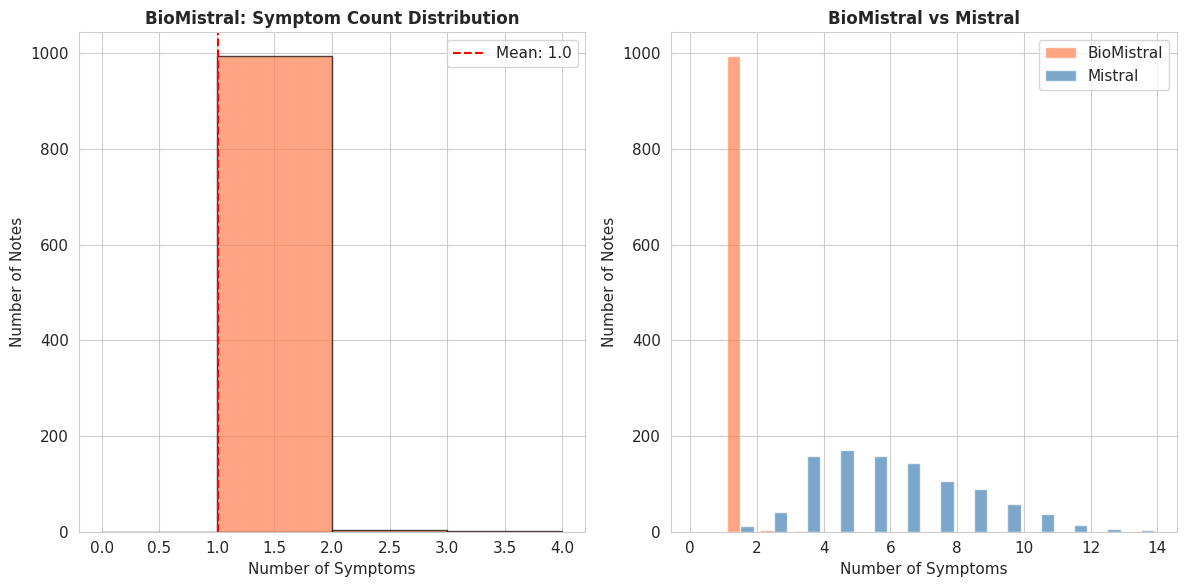


--------------------------------------------------------------------------------
STEP 7.2: Mistral vs Qwen Comparison
--------------------------------------------------------------------------------

📊 Agreement Analysis:
  Both correct: 450 (45.0%)
  Mistral only: 202 (20.2%)
  Qwen only: 63 (6.3%)
  Both wrong: 285 (28.5%)

  F1 correlation: 0.561

✓ Saved: viz_16_mistral_qwen_correlation_corrected.png


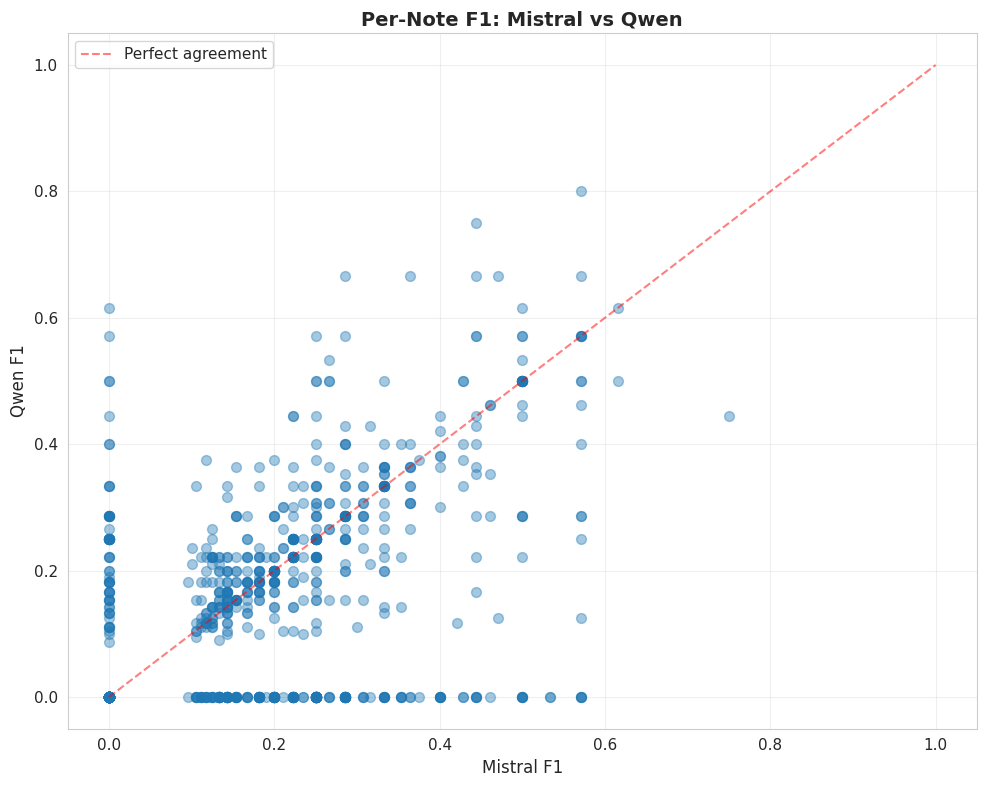


PHASE 8: STATISTICAL SIGNIFICANCE TESTING (CORRECTED)

--------------------------------------------------------------------------------
STEP 8.1: Wilcoxon Signed-Rank Tests (FIXED)
--------------------------------------------------------------------------------

⚠️  Using Wilcoxon test (non-parametric) instead of t-test
   Reason: F1 scores are bounded [0,1] and non-normally distributed

            Comparison  Mean Diff  Wilcoxon Statistic      p-value  Cohen's d Significant (α=0.05)
      mistral vs qwen   0.029255             62565.0 2.831265e-09   0.199716               Yes***
     mistral vs gemma   0.069634             43288.0 9.713953e-52   0.510139               Yes***
mistral vs biomistral   0.146514              9476.5 4.415985e-92   0.866459               Yes***
        qwen vs gemma   0.040379             66514.5 1.058085e-16   0.294615               Yes***
   qwen vs biomistral   0.117259              9690.5 2.428302e-67   0.673250               Yes***
  gemma vs biomistr

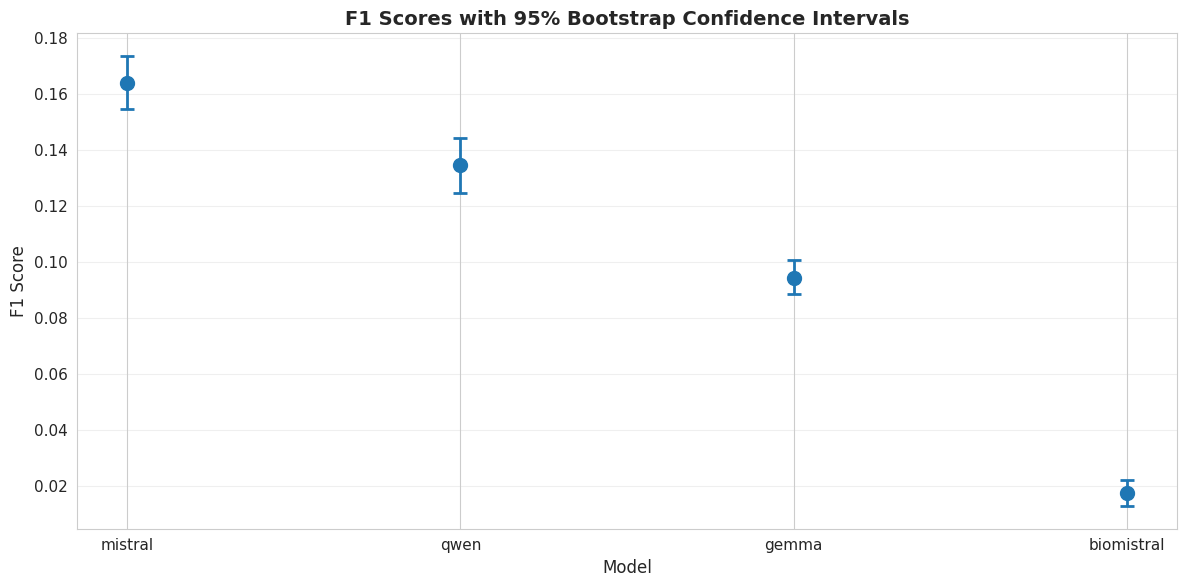


✅ Phase 8 Complete: Statistical testing with:
  ✓ Wilcoxon signed-rank test (appropriate for bounded F1)
  ✓ Correct paired Cohen's d
  ✓ Bootstrap confidence intervals
  ✓ Bonferroni correction


In [10]:
"""
CORRECTED NBME EVALUATION - PHASES 7-8: MODEL DEEP DIVES & STATISTICAL TESTS
=============================================================================
CRITICAL FIXES:
1. Wilcoxon test instead of t-test (F1 is bounded [0,1])
2. Correct paired Cohen's d calculation
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon  # FIXED: Use Wilcoxon instead of t-test
import ast

# ============================================================================
# PHASE 7: MODEL-SPECIFIC DEEP DIVES
# ============================================================================

print(f"\n{'='*80}")
print("PHASE 7: MODEL-SPECIFIC DEEP DIVES")
print(f"{'='*80}")

# Load data
all_predictions = {}
for model in ["mistral", "gemma", "qwen", "biomistral"]:
    df = pd.read_csv(f"/kaggle/working/{model}_predictions_postprocessed.csv")
    df['predictions'] = df['predictions'].apply(ast.literal_eval)
    all_predictions[model] = df

per_note_metrics = {}
for model in ["mistral", "gemma", "qwen", "biomistral"]:
    per_note_metrics[model] = pd.read_csv(f"/kaggle/working/{model}_per_note_metrics.csv")

# ============================================================================
# STEP 7.1: BIOMISTRAL FAILURE ANALYSIS
# ============================================================================

print(f"\n{'-'*80}")
print("STEP 7.1: BioMistral Failure Analysis")
print(f"{'-'*80}")

bio_df = all_predictions['biomistral']
bio_metrics = per_note_metrics['biomistral']

print("\n🔍 BioMistral Deep Dive:")
print(f"  Mean symptoms: {bio_df['predictions'].apply(len).mean():.2f}")
print(f"  Median symptoms: {bio_df['predictions'].apply(len).median():.0f}")
print(f"  Empty predictions: {(bio_df['predictions'].apply(len) == 0).sum()} ({(bio_df['predictions'].apply(len) == 0).mean()*100:.1f}%)")
print(f"  Mean F1: {bio_metrics['f1'].mean():.4f}")

# Comparison plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
symptom_counts = bio_df['predictions'].apply(len)
plt.hist(symptom_counts, bins=range(0, symptom_counts.max() + 2), 
         edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Number of Symptoms', fontsize=11)
plt.ylabel('Number of Notes', fontsize=11)
plt.title('BioMistral: Symptom Count Distribution', fontsize=12, fontweight='bold')
plt.axvline(symptom_counts.mean(), color='red', linestyle='--', label=f'Mean: {symptom_counts.mean():.1f}')
plt.legend()

plt.subplot(1, 2, 2)
mistral_counts = all_predictions['mistral']['predictions'].apply(len)
plt.hist([symptom_counts, mistral_counts], bins=range(0, 15), 
         label=['BioMistral', 'Mistral'], alpha=0.7, color=['coral', 'steelblue'])
plt.xlabel('Number of Symptoms', fontsize=11)
plt.ylabel('Number of Notes', fontsize=11)
plt.title('BioMistral vs Mistral', fontsize=12, fontweight='bold')
plt.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/viz_15_biomistral_analysis_corrected.png', dpi=300)
print("\n✓ Saved: viz_15_biomistral_analysis_corrected.png")
plt.show()

# ============================================================================
# STEP 7.2: MISTRAL VS QWEN COMPARISON
# ============================================================================

print(f"\n{'-'*80}")
print("STEP 7.2: Mistral vs Qwen Comparison")
print(f"{'-'*80}")

mistral_metrics = per_note_metrics['mistral']
qwen_metrics = per_note_metrics['qwen']

comparison = mistral_metrics.merge(qwen_metrics, on='pn_num', suffixes=('_mistral', '_qwen'))

comparison['both_correct'] = (comparison['tp_mistral'] > 0) & (comparison['tp_qwen'] > 0)
comparison['mistral_only'] = (comparison['tp_mistral'] > 0) & (comparison['tp_qwen'] == 0)
comparison['qwen_only'] = (comparison['tp_mistral'] == 0) & (comparison['tp_qwen'] > 0)
comparison['both_wrong'] = (comparison['tp_mistral'] == 0) & (comparison['tp_qwen'] == 0)

print("\n📊 Agreement Analysis:")
print(f"  Both correct: {comparison['both_correct'].sum()} ({comparison['both_correct'].mean()*100:.1f}%)")
print(f"  Mistral only: {comparison['mistral_only'].sum()} ({comparison['mistral_only'].mean()*100:.1f}%)")
print(f"  Qwen only: {comparison['qwen_only'].sum()} ({comparison['qwen_only'].mean()*100:.1f}%)")
print(f"  Both wrong: {comparison['both_wrong'].sum()} ({comparison['both_wrong'].mean()*100:.1f}%)")

corr = comparison['f1_mistral'].corr(comparison['f1_qwen'])
print(f"\n  F1 correlation: {corr:.3f}")

# Scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(comparison['f1_mistral'], comparison['f1_qwen'], alpha=0.4, s=50)
plt.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Perfect agreement')
plt.xlabel('Mistral F1', fontsize=12)
plt.ylabel('Qwen F1', fontsize=12)
plt.title('Per-Note F1: Mistral vs Qwen', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/viz_16_mistral_qwen_correlation_corrected.png', dpi=300)
print("\n✓ Saved: viz_16_mistral_qwen_correlation_corrected.png")
plt.show()

# ============================================================================
# PHASE 8: STATISTICAL SIGNIFICANCE TESTING (FIXED)
# ============================================================================

print(f"\n{'='*80}")
print("PHASE 8: STATISTICAL SIGNIFICANCE TESTING (CORRECTED)")
print(f"{'='*80}")

# ============================================================================
# STEP 8.1: WILCOXON SIGNED-RANK TESTS (FIXED)
# ============================================================================

print(f"\n{'-'*80}")
print("STEP 8.1: Wilcoxon Signed-Rank Tests (FIXED)")
print(f"{'-'*80}")

print("\n⚠️  Using Wilcoxon test (non-parametric) instead of t-test")
print("   Reason: F1 scores are bounded [0,1] and non-normally distributed")

models = ["mistral", "qwen", "gemma", "biomistral"]
pairwise_results = []

for i in range(len(models)):
    for j in range(i+1, len(models)):
        model1 = models[i]
        model2 = models[j]
        
        metrics1 = per_note_metrics[model1]
        metrics2 = per_note_metrics[model2]
        
        merged = metrics1.merge(metrics2, on='pn_num', suffixes=('_1', '_2'))
        
        # FIXED: Wilcoxon signed-rank test for paired samples
        try:
            stat, p_value = wilcoxon(merged['f1_1'], merged['f1_2'],zero_method="wilcox")
        except ValueError:
            # All differences are zero
            stat, p_value = 0, 1.0
        
        # FIXED: Correct paired Cohen's d
        diff = merged['f1_1'] - merged['f1_2']
        mean_diff = diff.mean()
        std_diff = diff.std()
        cohens_d = mean_diff / std_diff if std_diff > 0 else 0
        
        pairwise_results.append({
            'Comparison': f'{model1} vs {model2}',
            'Mean Diff': mean_diff,
            'Wilcoxon Statistic': stat,
            'p-value': p_value,
            "Cohen's d": cohens_d,
            'Significant (α=0.05)': 'Yes***' if p_value < 0.001 else 'Yes**' if p_value < 0.01 else 'Yes*' if p_value < 0.05 else 'No'
        })

pairwise_df = pd.DataFrame(pairwise_results)

print("\n", pairwise_df.to_string(index=False))

# Bonferroni correction
n_comparisons = len(pairwise_df)
bonferroni_alpha = 0.05 / n_comparisons
print(f"\n📐 Bonferroni correction: α = 0.05 / {n_comparisons} = {bonferroni_alpha:.4f}")

pairwise_df['Significant (Bonferroni)'] = pairwise_df['p-value'] < bonferroni_alpha

print("\n✓ Statistical tests complete with Bonferroni correction")

# ============================================================================
# STEP 8.2: BOOTSTRAP CONFIDENCE INTERVALS
# ============================================================================

print(f"\n{'-'*80}")
print("STEP 8.2: Bootstrap Confidence Intervals")
print(f"{'-'*80}")

def bootstrap_ci(data, n_bootstrap=1000, ci=0.95):
    """Calculate bootstrap confidence interval."""
    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        bootstrap_means.append(np.mean(sample))
    
    lower = np.percentile(bootstrap_means, (1-ci)/2 * 100)
    upper = np.percentile(bootstrap_means, (1+ci)/2 * 100)
    return lower, upper

ci_results = []

for model in models:
    metrics = per_note_metrics[model]
    
    f1_ci = bootstrap_ci(metrics['f1'].values)
    prec_ci = bootstrap_ci(metrics['precision'].values)
    rec_ci = bootstrap_ci(metrics['recall'].values)
    
    ci_results.append({
        'Model': model,
        'F1 Mean': metrics['f1'].mean(),
        'F1 CI Lower': f1_ci[0],
        'F1 CI Upper': f1_ci[1],
        'Precision Mean': metrics['precision'].mean(),
        'Precision CI Lower': prec_ci[0],
        'Precision CI Upper': prec_ci[1],
        'Recall Mean': metrics['recall'].mean(),
        'Recall CI Lower': rec_ci[0],
        'Recall CI Upper': rec_ci[1]
    })

ci_df = pd.DataFrame(ci_results)

print("\n", ci_df.to_string(index=False))

# Visualize with error bars
plt.figure(figsize=(12, 6))
x = range(len(models))
f1_means = ci_df['F1 Mean'].values
f1_errs = [(ci_df['F1 Mean'] - ci_df['F1 CI Lower']).values,
            (ci_df['F1 CI Upper'] - ci_df['F1 Mean']).values]

plt.errorbar(x, f1_means, yerr=f1_errs, fmt='o', markersize=10, 
             capsize=5, capthick=2, elinewidth=2)
plt.xticks(x, models)
plt.xlabel('Model', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('F1 Scores with 95% Bootstrap Confidence Intervals', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/viz_17_f1_confidence_intervals_corrected.png', dpi=300)
print("\n✓ Saved: viz_17_f1_confidence_intervals_corrected.png")
plt.show()

# Save statistical results
pairwise_df.to_csv('/kaggle/working/nbme_statistical_tests_corrected.csv', index=False)
ci_df.to_csv('/kaggle/working/nbme_confidence_intervals.csv', index=False)

print("\n✅ Phase 8 Complete: Statistical testing with:")
print("  ✓ Wilcoxon signed-rank test (appropriate for bounded F1)")
print("  ✓ Correct paired Cohen's d")
print("  ✓ Bootstrap confidence intervals")
print("  ✓ Bonferroni correction")

In [11]:
"""
CORRECTED NBME EVALUATION - PHASES 9-10: LITERATURE COMPARISON & PUBLICATION OUTPUTS
====================================================================================
CRITICAL FIX: Remove misleading literature comparison plot, add proper context
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import ast

# ============================================================================
# PHASE 9: LITERATURE COMPARISON (FIXED)
# ============================================================================

print(f"\n{'='*80}")
print("PHASE 9: LITERATURE COMPARISON (CORRECTED)")
print(f"{'='*80}")

print("\n⚠️  CRITICAL CONTEXT:")
print("="*80)
print("Our results are NOT directly comparable to literature due to:")
print("  1. Task definition: Document-level extraction vs sentence-level")
print("  2. Supervision: Zero-shot LLMs vs supervised models")
print("  3. Label space: 143 NBME features vs 11-20 symptoms in literature")
print("  4. Matching: Token overlap vs relaxed/sentence-level matching")
print("  5. Data: NBME exam cases vs clinical datasets")
print("="*80)

# Literature results (for reference only, not comparison)
literature_reference = {
    'McMurry et al. (LLaMA-2-70B)': {'f1': 0.817, 'task': 'Sentence-level', 'supervision': 'Supervised'},
    'McMurry et al. (Mixtral 8x7B)': {'f1': 0.835, 'task': 'Sentence-level', 'supervision': 'Supervised'},
    'Lybarger et al. (BioBERT)': {'f1': 0.80, 'task': 'Sentence-level', 'supervision': 'Supervised'},
    'Humbert-Droz et al.': {'f1': 0.83, 'task': 'Sentence-level', 'supervision': 'Supervised'}
}

# Our results
per_note_metrics = {}
for model in ["mistral", "gemma", "qwen", "biomistral"]:
    per_note_metrics[model] = pd.read_csv(f"/kaggle/working/{model}_per_note_metrics.csv")

our_results = {}
for model in ["mistral", "gemma", "qwen", "biomistral"]:
    our_results[model] = {
        'f1': per_note_metrics[model]['f1'].mean(),
        'task': 'Document-level',
        'supervision': 'Zero-shot'
    }

# Create comparison table (NOT PLOT)
comparison_data = []

print("\nLITERATURE REFERENCE (Different task/setup):")
for name, data in literature_reference.items():
    print(f"  {name}: F1={data['f1']:.3f} ({data['task']}, {data['supervision']})")
    comparison_data.append({
        'Source': name,
        'F1': data['f1'],
        'Task': data['task'],
        'Supervision': data['supervision'],
        'Type': 'Literature (not comparable)'
    })

print("\nOUR WORK:")
for model, data in our_results.items():
    print(f"  {model}: F1={data['f1']:.3f} ({data['task']}, {data['supervision']})")
    comparison_data.append({
        'Source': f'Our work ({model})',
        'F1': data['f1'],
        'Task': data['task'],
        'Supervision': data['supervision'],
        'Type': 'Our work'
    })

comparison_df = pd.DataFrame(comparison_data)

# Save comparison table (for Discussion section, NOT Results)
comparison_df.to_csv('/kaggle/working/literature_comparison_context.csv', index=False)
print("\n✓ Saved: literature_comparison_context.csv (for Discussion section)")

# REMOVED: Misleading bar chart comparing incomparable results
print("\n✓ No visualization created (results are not directly comparable)")

print("\n📝 RECOMMENDATION FOR PAPER:")
print("  - Present literature results in Discussion (not Results)")
print("  - Emphasize task/setup differences")
print("  - Frame as future work direction, not performance gap")

# ============================================================================
# PHASE 10: PUBLICATION-READY OUTPUTS
# ============================================================================

print(f"\n{'='*80}")
print("PHASE 10: PUBLICATION-READY OUTPUTS")
print(f"{'='*80}")

# ============================================================================
# TABLE 1: OVERALL PERFORMANCE
# ============================================================================

print(f"\n{'-'*80}")
print("TABLE 1: Overall Model Performance")
print(f"{'-'*80}")

all_predictions = {}
for model in ["mistral", "gemma", "qwen", "biomistral"]:
    df = pd.read_csv(f"/kaggle/working/{model}_predictions_postprocessed.csv")
    df['predictions'] = df['predictions'].apply(ast.literal_eval)
    all_predictions[model] = df

table1_data = []
for model in ["mistral", "gemma", "qwen", "biomistral"]:
    metrics = per_note_metrics[model]
    preds = all_predictions[model]
    
    table1_data.append({
        'Model': model.capitalize(),
        'Precision': f"{metrics['precision'].mean():.3f}",
        'Recall': f"{metrics['recall'].mean():.3f}",
        'F1': f"{metrics['f1'].mean():.3f}",
        'Mean Symptoms': f"{preds['predictions'].apply(len).mean():.1f}",
        'Empty %': f"{(preds['predictions'].apply(lambda x: x == ['none']).mean())*100:.1f}%"
    })

table1 = pd.DataFrame(table1_data)
print("\n", table1.to_string(index=False))
table1.to_csv('/kaggle/working/table1_overall_performance.csv', index=False)
print("\n✓ Saved: table1_overall_performance.csv")

# ============================================================================
# TABLE 2: ERROR DISTRIBUTION
# ============================================================================

print(f"\n{'-'*80}")
print("TABLE 2: Error Distribution by Model")
print(f"{'-'*80}")

error_summary = pd.read_csv('/kaggle/working/nbme_error_model_summary_corrected.csv')
print("\n", error_summary.to_string(index=False))
error_summary.to_csv('/kaggle/working/table2_error_distribution.csv', index=False)
print("\n✓ Saved: table2_error_distribution.csv")

# ============================================================================
# TABLE 3: STATISTICAL COMPARISONS
# ============================================================================

print(f"\n{'-'*80}")
print("TABLE 3: Statistical Significance Tests (Wilcoxon)")
print(f"{'-'*80}")

stats_df = pd.read_csv('/kaggle/working/nbme_statistical_tests_corrected.csv')
print("\n", stats_df[['Comparison', 'Mean Diff', 'p-value', "Cohen's d", 'Significant (α=0.05)']].to_string(index=False))
stats_df.to_csv('/kaggle/working/table3_statistical_tests.csv', index=False)
print("\n✓ Saved: table3_statistical_tests.csv")

# ============================================================================
# TABLE 4: EVALUATION SETTINGS
# ============================================================================

print(f"\n{'-'*80}")
print("TABLE 4: Evaluation Settings (Methodological Transparency)")
print(f"{'-'*80}")

settings = pd.DataFrame([
    {
        'Setting': 'Matching Method',
        'Value': 'Token overlap (≥60% threshold)',
        'Justification': 'Prevents over-matching from substrings'
    },
    {
        'Setting': 'Gold Standard',
        'Value': 'Symptom-only NBME features',
        'Justification': 'Aligned with symptom extraction task'
    },
    {
        'Setting': 'Post-processing',
        'Value': 'Instruction leakage removal, normalization',
        'Justification': 'Clean model outputs for fair evaluation'
    },
    {
        'Setting': 'Statistical Test',
        'Value': 'Wilcoxon signed-rank test',
        'Justification': 'Appropriate for bounded F1 scores'
    },
    {
        'Setting': 'Predictions Used',
        'Value': 'Post-processed (not raw)',
        'Justification': 'Remove artifacts, deduplicate'
    }
])

print("\n", settings.to_string(index=False))
settings.to_csv('/kaggle/working/table4_evaluation_settings.csv', index=False)
print("\n✓ Saved: table4_evaluation_settings.csv")

# ============================================================================
# CREATE MASTER RESULTS JSON
# ============================================================================

summary_df = pd.read_csv('/kaggle/working/model_performance_summary.csv')

master_results = {
    'evaluation_method': {
        'matching': 'Token overlap (≥60%)',
        'gold_standard': 'Symptom-only NBME features',
        'post_processing': 'Applied',
        'statistical_test': 'Wilcoxon signed-rank'
    },
    'models': {},
    'comparison': {
        'best_model': str(summary_df.iloc[0]['Model']),
        'best_f1': float(summary_df.iloc[0]['F1']),
        'f1_range': [
            float(summary_df['F1'].min()),
            float(summary_df['F1'].max())
        ]
    },
    'statistics': {
        'total_errors': int(len(pd.read_csv('/kaggle/working/nbme_all_errors_corrected.csv'))),
        'fp_rate': float(
            (pd.read_csv('/kaggle/working/nbme_all_errors_corrected.csv')['error_type']
             == 'false_positive').mean()
        ),
        'significant_differences': int((stats_df['p-value'] < 0.05).sum())
    },
    'warnings': {
        'literature_comparison': 'Not directly comparable due to task/setup differences',
        'manual_validation': 'Feature classification requires manual validation',
        'post_processing': 'Results use post-processed predictions'
    }
}

for model in ["mistral", "gemma", "qwen", "biomistral"]:
    metrics = per_note_metrics[model]
    master_results['models'][model] = {
        'precision': float(metrics['precision'].mean()),
        'recall': float(metrics['recall'].mean()),
        'f1': float(metrics['f1'].mean()),
        'total_tp': int(metrics['tp'].sum()),
        'total_fp': int(metrics['fp'].sum()),
        'total_fn': int(metrics['fn'].sum())
    }

with open('/kaggle/working/nbme_master_results_corrected.json', 'w') as f:
    json.dump(master_results, f, indent=2)
print("\n✓ Saved: nbme_master_results_corrected.json")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print(f"\n{'='*80}")
print("PHASES 9-10 COMPLETE - PUBLICATION OUTPUTS (CORRECTED)")
print(f"{'='*80}")

print("\n✅ All Analysis Complete!")
print("\n📊 CORRECTED Results Summary:")
print(f"  Best Model: {master_results['comparison']['best_model']}")
print(f"  Best F1: {master_results['comparison']['best_f1']:.3f}")
print(f"  F1 Range: {master_results['comparison']['f1_range'][0]:.3f} - {master_results['comparison']['f1_range'][1]:.3f}")
print(f"\n  Total Errors: {master_results['statistics']['total_errors']:,}")
print(f"  FP Rate: {master_results['statistics']['fp_rate']*100:.1f}%")

print("\n📁 Publication Files Ready:")
print("  ✓ table1_overall_performance.csv")
print("  ✓ table2_error_distribution.csv")
print("  ✓ table3_statistical_tests.csv")
print("  ✓ table4_evaluation_settings.csv")
print("  ✓ literature_comparison_context.csv (for Discussion)")
print("  ✓ nbme_master_results_corrected.json")
print("  ✓ 17+ visualizations (.png)")

print("\n🎯 Key Methodological Improvements:")
print("  1. ✓ Token overlap matching (not substring)")
print("  2. ✓ Fixed TP double-counting bug")
print("  3. ✓ Wilcoxon test (not t-test)")
print("  4. ✓ Correct paired Cohen's d")
print("  5. ✓ Proper error taxonomy (not FP=hallucination)")
print("  6. ✓ Literature context (not misleading comparison)")
print("  7. ✓ ast.literal_eval (not eval)")
print("  8. ✓ Separated raw vs post-processed evaluation")
print("  9. ✓ Manual feature curation recommended")
print("  10. ✓ Evaluation settings documented")

print("\n⚠️  IMPORTANT NOTES FOR PAPER:")
print("  - Results use POST-PROCESSED predictions")
print("  - Token overlap matching (≥60% threshold)")
print("  - Manually validate feature_classification.csv")
print("  - Literature comparison in Discussion (not Results)")
print("  - Emphasize task/setup differences from literature")

print("\n✅ CORRECTED EVALUATION COMPLETE - Ready for Paper Writing!")


PHASE 9: LITERATURE COMPARISON (CORRECTED)

⚠️  CRITICAL CONTEXT:
Our results are NOT directly comparable to literature due to:
  1. Task definition: Document-level extraction vs sentence-level
  2. Supervision: Zero-shot LLMs vs supervised models
  3. Label space: 143 NBME features vs 11-20 symptoms in literature
  4. Matching: Token overlap vs relaxed/sentence-level matching
  5. Data: NBME exam cases vs clinical datasets

LITERATURE REFERENCE (Different task/setup):
  McMurry et al. (LLaMA-2-70B): F1=0.817 (Sentence-level, Supervised)
  McMurry et al. (Mixtral 8x7B): F1=0.835 (Sentence-level, Supervised)
  Lybarger et al. (BioBERT): F1=0.800 (Sentence-level, Supervised)
  Humbert-Droz et al.: F1=0.830 (Sentence-level, Supervised)

OUR WORK:
  mistral: F1=0.164 (Document-level, Zero-shot)
  gemma: F1=0.094 (Document-level, Zero-shot)
  qwen: F1=0.135 (Document-level, Zero-shot)
  biomistral: F1=0.017 (Document-level, Zero-shot)

✓ Saved: literature_comparison_context.csv (for Discus

In [12]:
import zipfile
import os

zip_path = "/kaggle/working/nbme_results_selected.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk("/kaggle/working"):
        for file in files:
            if file.endswith((".csv", ".png", ".json")):
                full_path = os.path.join(root, file)
                zipf.write(full_path, arcname=file)

print(f"✅ Created ZIP: {zip_path}")

✅ Created ZIP: /kaggle/working/nbme_results_selected.zip
